# E2 — Contexto: Context Size
## Pregunta de investigación

¿Cómo afecta la longitud de contexto a las métricas de rendimiento?

## Hipótesis previa

Mayor context_size aumenta memoria y puede reducir throughput, pero no debería afectar TTFT.

## Configuración del experimento

| Parámetro | Valores |
|-----------|---------|
| Modelo | Todos |
| Context Size | 512, 1024, 2048, 4096 |
| Total | Múltiples runs |

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.transforms.collection import RunCollection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# --- Carga de datos (E2) ---
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "TFG-DATA" / "E2"

assert DATA_ROOT.is_dir(), f"No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
print(f"Runs cargados E2: {len(coll)}")

# --- Filtrado para E2: todos los modelos × 5 context sizes ---
# Se incluyen todos los modelos para que FoM_full pueda encontrar la fila
# de referencia (Llama-3.2-3B, ctx=4096, bs=512, seed=42).
summary = coll.summary_df()
hw_full = coll.hw_metrics_df()
pm_full = coll.prompt_metrics_df()

ex = summary[summary["accelerator"] == False].copy()

# Preferir TYPE_2 si existe; si no, usar TYPE_1
if "TYPE_2" in ex["test_type"].values:
    ex = ex[ex["test_type"] == "TYPE_2"].copy()
elif "TYPE_1" in ex["test_type"].values:
    ex = ex[ex["test_type"] == "TYPE_1"].copy()

print(f"Runs en E2: {ex.shape[0]}")
if len(ex) > 0:
    print(f"Modelos: {sorted(ex['model_label'].unique())}")
    print(f"Context sizes: {sorted(ex['context_size'].dropna().unique())}")
else:
    print("Sin datos disponibles para este experimento")


Runs cargados E2: 30
Runs en E2: 30
Modelos: ['DeepSeek-R1-1.5B (L)', 'Llama-3.2-1B (L)', 'Llama-3.2-3B (L)', 'gemma (L)', 'granite (L)', 'ministral (L)']
Context sizes: [np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096), np.int64(5120)]


# 📊 Figuras y tablas de la memoria

| # | Figura/Tabla |
|---|---|
| Tab. 1 | Tabla maestra E2: modelo × contexto (RAM, tok/s, TTFT, J/tok, MBU, η_CPU, PPL, FoM, Usable) |
| Fig. 1 | Huella RAM medida (hw) vs context_size — crecimiento de caché KV |
| Fig. 2 | Throughput (tok/s) vs context_size con umbral T_hum |
| Fig. 3 | FoM_full vs context_size (punto óptimo de contexto) |
| Fig. 4 | TTFT vs context_size (coste de prefill) |

In [2]:
# ── Tab. 1 — Tabla maestra E2: modelo × contexto ────────────────────────────
from monitorviz.transforms.fom import compute_fom_full, compute_usability
try:
    _fom = compute_fom_full(ex)
    if not pm_full.empty:
        _fom, _ = compute_usability(_fom, pm_full)
    else:
        _fom["usable"] = False

    # σ desde métricas por prompt (variabilidad intra-run)
    if not pm_full.empty and "run_id" in pm_full.columns and "run_id" in _fom.columns:
        _valid_pm2 = (pm_full[~pm_full["is_empty_generation"]]
                      if "is_empty_generation" in pm_full.columns else pm_full)
        _std_cols2 = [c for c in ["tokens_per_second", "time_to_first_token_ms", "perplexity"]
                      if c in _valid_pm2.columns]
        if _std_cols2:
            _std_df2 = (
                _valid_pm2.groupby("run_id")[_std_cols2].std().reset_index()
                .rename(columns={"tokens_per_second":      "tokens_per_s_std",
                                 "time_to_first_token_ms": "ttft_ms_std",
                                 "perplexity":             "perplexity_std"})
            )
            _fom = _fom.merge(_std_df2, on="run_id", how="left")

    _COL_MAP = {
        "model_label":         "Modelo",
        "context_size":        "Contexto",
        "n_params":            "N params",
        "ram_used_gb":         "RAM (GB)",
        "tokens_per_s_mean":   "tok/s",
        "tokens_per_s_std":    "σ tok/s",
        "ttft_ms_mean":        "TTFT (ms)",
        "ttft_ms_std":         "σ TTFT",
        "energy_per_token_j":  "J/tok",
        "mbu_corr":            "MBU (%)",
        "cpu_efficiency":      "η_CPU",
       # "perplexity_geomean":  "PPL",
        "fom_full":            "FoM_full",
        "usable":              "Usable",
    }
    # RAM en runtime (mean hw_metrics) en GB métrico
    if not hw_full.empty and "mem_used_bytes" in hw_full.columns and "run_id" in _fom.columns:
        _ram_e2 = hw_full.groupby("run_id")["mem_used_bytes"].mean().reset_index()
        _ram_e2["ram_used_gb"] = _ram_e2["mem_used_bytes"] / 1e9
        _fom = _fom.merge(_ram_e2[["run_id", "ram_used_gb"]], on="run_id", how="left")

    _src = [c for c in _COL_MAP if c in _fom.columns]
    _tbl = _fom[_src].rename(columns=_COL_MAP).copy()
    _tbl = _tbl.sort_values(["Modelo", "Contexto"])
    if "N params" in _tbl.columns:
        _tbl["N params"] = _tbl["N params"].apply(
            lambda x: f"{x/1e9:.2f}B" if x == x else "—")
    if "Usable" in _tbl.columns:
        _tbl["Usable"] = _tbl["Usable"].map({True: "✓", False: "✗"})
    _ROUND = {"RAM (GB)": 2, "tok/s": 1, "σ tok/s": 1,
              "TTFT (ms)": 0, "σ TTFT": 0,
              "J/tok": 3, "MBU (%)": 1, "η_CPU": 3, "PPL": 2, "FoM_full": 3}
    for col, dec in _ROUND.items():
        if col in _tbl.columns:
            _tbl[col] = _tbl[col].round(dec)
    print("Tab. 1 — Tabla maestra E2")
    display(_tbl.reset_index(drop=True))
except Exception:
    import traceback; traceback.print_exc()


Tab. 1 — Tabla maestra E2


,Modelo,Contexto,N params,RAM (GB),tok/s,σ tok/s,TTFT (ms),σ TTFT,J/tok,MBU (%),η_CPU,FoM_full,Usable
0,DeepSeek-R1-1.5B (L),512,1.78B,1.42,11.1,0.1,924.0,550.0,0.651,73.3,0.945,1.164,✓
1,DeepSeek-R1-1.5B (L),1024,1.78B,1.43,10.8,0.1,919.0,557.0,0.650,72.3,0.959,1.156,✓
2,DeepSeek-R1-1.5B (L),2048,1.78B,1.45,10.3,0.3,927.0,556.0,0.681,70.5,0.967,1.124,✓
3,DeepSeek-R1-1.5B (L),4096,1.78B,1.51,9.1,1.2,951.0,556.0,0.767,64.3,0.974,1.036,✓
4,DeepSeek-R1-1.5B (L),5120,1.78B,1.54,8.7,1.6,948.0,561.0,0.813,62.1,0.977,1.002,✓
5,Llama-3.2-1B (L),512,1.24B,1.26,13.1,0.3,652.0,395.0,0.535,63.2,0.942,1.024,✓
6,Llama-3.2-1B (L),1024,1.24B,1.26,12.9,0.5,649.0,377.0,0.536,63.4,0.954,1.023,✓
7,Llama-3.2-1B (L),2048,1.24B,1.30,12.4,1.0,651.0,372.0,0.547,62.9,0.964,1.008,✓
8,Llama-3.2-1B (L),4096,1.24B,1.36,11.3,2.4,671.0,364.0,0.571,59.3,0.975,0.963,✓
9,Llama-3.2-1B (L),5120,1.24B,1.39,10.8,3.0,690.0,359.0,0.588,56.9,0.979,0.938,✓


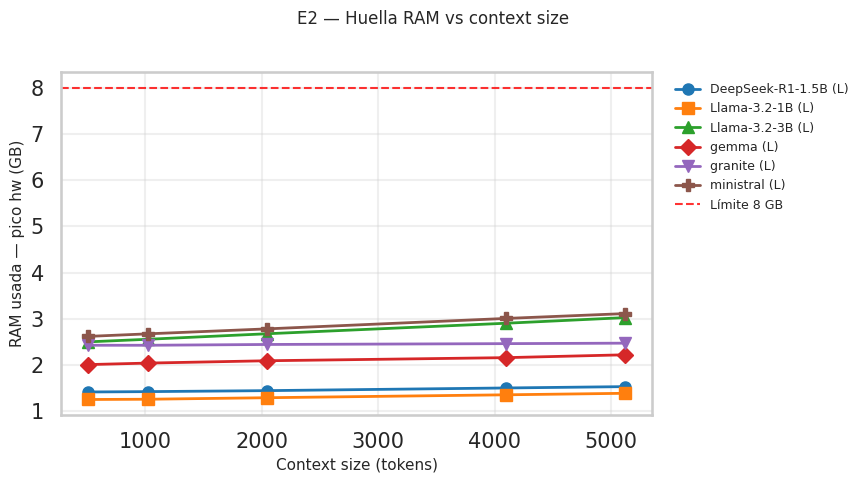

In [3]:
# ── Fig. 1 — Huella RAM medida (hw) vs context_size ─────────────────────────
try:
    _run_ids_e2 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    _hw_e2 = hw_full[hw_full["run_id"].isin(_run_ids_e2)] if not hw_full.empty else pd.DataFrame()

    if not _hw_e2.empty and "mem_used_bytes" in _hw_e2.columns:
        # Media de RAM usada por run durante inferencia
        _mem_peak = (
            _hw_e2.groupby("run_id")["mem_used_bytes"].mean()
            .reset_index()
            .rename(columns={"mem_used_bytes": "_mem_gb"})
        )
        _mem_peak["_mem_gb"] /= 1e9
        _ex_ram = ex.merge(_mem_peak, on="run_id", how="left")
        _ex_ram = _ex_ram.dropna(subset=["context_size", "_mem_gb"]).sort_values("context_size")

        fig, ax = plt.subplots(figsize=(9, 5))
        _MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X"]
        for i, _m in enumerate(sorted(_ex_ram["model_label"].unique())):
            _sub = _ex_ram[_ex_ram["model_label"] == _m]
            ax.plot(_sub["context_size"], _sub["_mem_gb"],
                    marker=_MARKER_POOL[i % len(_MARKER_POOL)], lw=2, ms=8, label=_m)
        ax.axhline(8.0, color="red", ls="--", lw=1.5, alpha=0.8, label="L\u00edmite 8 GB")
        ax.set_xlabel("Context size (tokens)", fontsize=11)
        ax.set_ylabel("RAM usada — pico hw (GB)", fontsize=11)
        fig.suptitle("E2 — Huella RAM vs context size", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
    else:
        print("Sin datos de hw mem — mostrando model_size_gb como aproximaci\u00f3n")
        _ex_r = ex.dropna(subset=["context_size", "model_size_gb"]).sort_values("context_size")
        if not _ex_r.empty:
            fig, ax = plt.subplots(figsize=(9, 5))
            for _m in sorted(_ex_r["model_label"].unique()):
                _sub = _ex_r[_ex_r["model_label"] == _m]
                ax.plot(_sub["context_size"], _sub["model_size_gb"], marker="o", lw=2, label=_m)
            ax.axhline(8.0, color="red", ls="--", lw=1.5, label="L\u00edmite 8 GB")
            ax.set_xlabel("Context size (tokens)"); ax.set_ylabel("RAM modelo (GB)")
            fig.suptitle("E2 — Huella RAM (modelo) vs context size"); ax.grid(True, alpha=0.3)
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
            fig.tight_layout(); plt.show()
except Exception:
    import traceback; traceback.print_exc()


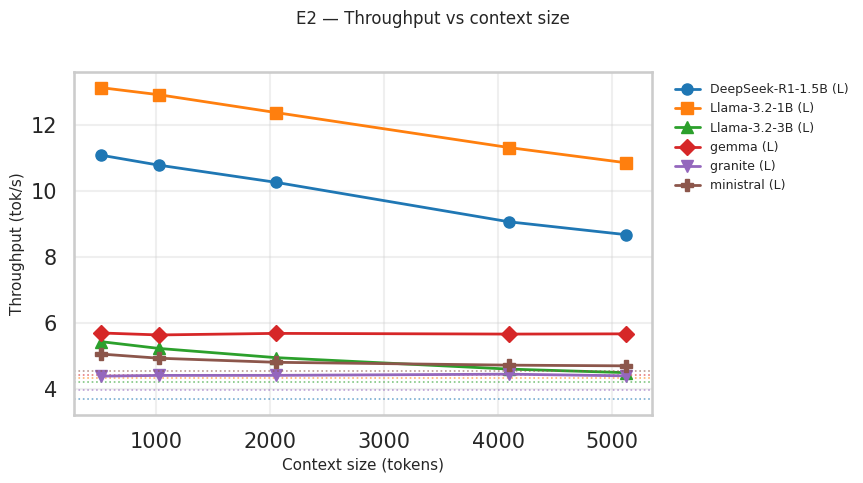

In [4]:
# ── Fig. 2 — Throughput (tok/s) vs context_size + T_hum ─────────────────────
from monitorviz.transforms.fom import compute_usability
try:
    _ex_t = ex.dropna(subset=["context_size", "tokens_per_s_mean"]).sort_values("context_size")
    if _ex_t.empty:
        print("Sin datos tokens_per_s_mean / context_size")
    else:
        # Umbral T_hum por modelo
        _fom_t = compute_fom_full(ex) if "fom_full" not in ex.columns else ex.copy()
        if not pm_full.empty:
            _fom_t, _tpw = compute_usability(_fom_t, pm_full)
            _thum = _fom_t.groupby("model_label")["T_hum"].first().to_dict()
        else:
            _thum = {}

        _MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X"]
        fig, ax = plt.subplots(figsize=(9, 5))
        for i, _m in enumerate(sorted(_ex_t["model_label"].unique())):
            _sub = _ex_t[_ex_t["model_label"] == _m]
            ax.plot(_sub["context_size"], _sub["tokens_per_s_mean"],
                    marker=_MARKER_POOL[i % len(_MARKER_POOL)], lw=2, ms=8, label=_m)
            if _m in _thum:
                ax.axhline(_thum[_m], ls=":", lw=1.2, alpha=0.6,
                           color=ax.lines[-1].get_color())

        # Línea T_hum global (si hay un único modelo)
        if len(_thum) == 1:
            _th_val = list(_thum.values())[0]
            ax.axhline(_th_val, color="black", ls="--", lw=1.5, alpha=0.8,
                       label=f"T_hum \u2248 {_th_val:.1f} tok/s")

        ax.set_xlabel("Context size (tokens)", fontsize=11)
        ax.set_ylabel("Throughput (tok/s)", fontsize=11)
        fig.suptitle("E2 — Throughput vs context size", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
except Exception:
    import traceback; traceback.print_exc()


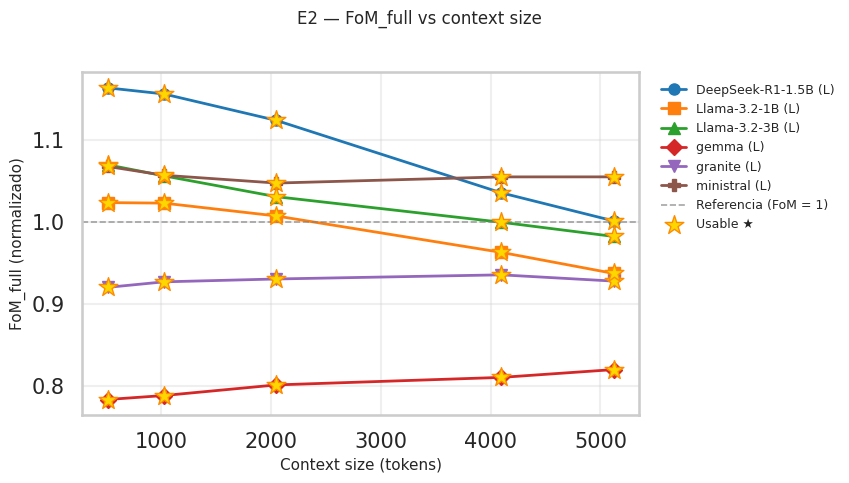

In [5]:
# ── Fig. 3 — FoM_full vs context_size por modelo ─────────────────────────────
from monitorviz.transforms.fom import compute_fom_full, compute_usability
try:
    _fom3 = compute_fom_full(ex)
    if not pm_full.empty:
        _fom3, _ = compute_usability(_fom3, pm_full)
    else:
        _fom3["usable"] = False

    _fd3 = _fom3.dropna(subset=["context_size", "fom_full"]).sort_values("context_size")
    if _fd3.empty:
        print("Sin datos FoM_full/context_size")
    else:
        _MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X"]
        fig, ax = plt.subplots(figsize=(9, 5))
        for i, _m in enumerate(sorted(_fd3["model_label"].unique())):
            _sub = _fd3[_fd3["model_label"] == _m]
            ax.plot(_sub["context_size"], _sub["fom_full"],
                    marker=_MARKER_POOL[i % len(_MARKER_POOL)], lw=2, ms=8, label=_m)
        ax.axhline(1.0, color="gray", ls="--", lw=1.2, alpha=0.7, label="Referencia (FoM = 1)")
        # Marcar usables con ★
        if "usable" in _fd3.columns and _fd3["usable"].any():
            _us3 = _fd3[_fd3["usable"]]
            ax.scatter(_us3["context_size"], _us3["fom_full"],
                       s=200, marker="*", color="gold", zorder=5,
                       edgecolors="darkorange", lw=1, label="Usable \u2605")
        ax.set_xlabel("Context size (tokens)", fontsize=11)
        ax.set_ylabel("FoM_full (normalizado)", fontsize=11)
        fig.suptitle("E2 — FoM_full vs context size", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
except Exception:
    import traceback; traceback.print_exc()


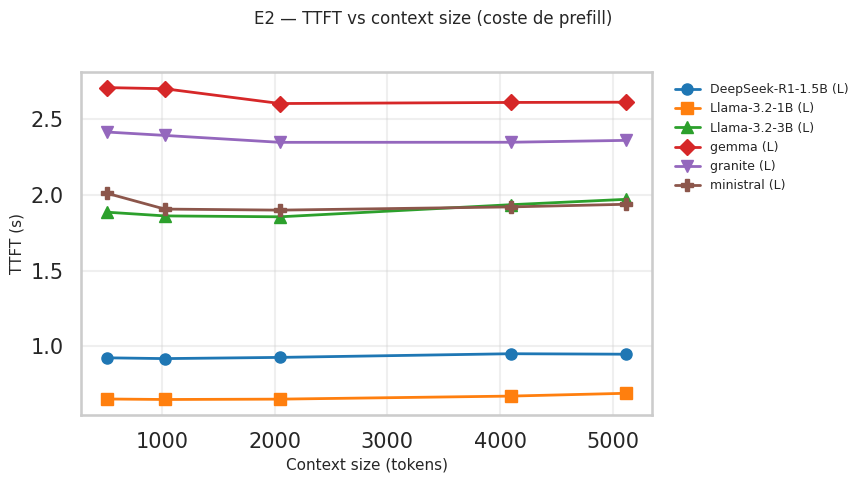

In [6]:
# ── Fig. 4 — TTFT vs context_size (coste de prefill) ────────────────────────
try:
    _ex_tt = ex.dropna(subset=["context_size", "ttft_ms_mean"]).sort_values("context_size")
    if _ex_tt.empty:
        print("Sin datos TTFT / context_size")
    else:
        _MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X"]
        fig, ax = plt.subplots(figsize=(9, 5))
        for i, _m in enumerate(sorted(_ex_tt["model_label"].unique())):
            _sub = _ex_tt[_ex_tt["model_label"] == _m]
            ax.plot(_sub["context_size"], _sub["ttft_ms_mean"] / 1000,
                    marker=_MARKER_POOL[i % len(_MARKER_POOL)], lw=2, ms=8, label=_m)
        ax.set_xlabel("Context size (tokens)", fontsize=11)
        ax.set_ylabel("TTFT (s)", fontsize=11)
        fig.suptitle("E2 — TTFT vs context size (coste de prefill)", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
except Exception:
    import traceback; traceback.print_exc()


---
# 📎 ANEXO — Material complementario (no incluido en la memoria principal)
---

Las siguientes figuras se conservan para validación y detalle; no forman parte de las 5–6 de la memoria principal.

## Resumen ejecutivo
> TODO: Actualizar con resultados finales.

In [7]:
# ── Anexo: Tablas comparativas E2 (inferencia + hardware con σ) ─────
if not ex.empty:
    from monitorviz.transforms.fom import compute_fom_full, compute_usability

    try:
        from monitorviz.transforms.fom import compute_fom_full, compute_usability
        _df_ann = compute_fom_full(ex)
        if not pm_full.empty:
            _df_ann, _ = compute_usability(_df_ann, pm_full)
        else:
            _df_ann["fom_full"] = float("nan")
            _df_ann["usable"] = False
    except Exception:
        _df_ann = ex.copy()
        _df_ann["fom_full"] = float("nan")
        _df_ann["usable"] = False

    # σ inferencia desde pm_full por prompt
    if not pm_full.empty and "run_id" in pm_full.columns and "run_id" in _df_ann.columns:
        _valid_ann = (pm_full[~pm_full["is_empty_generation"]]
                      if "is_empty_generation" in pm_full.columns else pm_full)
        _si_ann = [c for c in ["tokens_per_second","time_to_first_token_ms","perplexity"]
                   if c in _valid_ann.columns]
        if _si_ann:
            _std_inf_ann = (_valid_ann.groupby("run_id")[_si_ann].std().reset_index()
                            .rename(columns={
                                "tokens_per_second":      "tokens_per_s_std",
                                "time_to_first_token_ms": "ttft_ms_std",
                                "perplexity":             "perplexity_std",
                            }))
            _df_ann = _df_ann.merge(_std_inf_ann, on="run_id", how="left")

    # σ hardware desde hw_full por muestra
    if not hw_full.empty and "run_id" in hw_full.columns and "run_id" in _df_ann.columns:
        _sh_ann = [c for c in ["temperature_c","internal_power_w","freq_mean_ghz"]
                   if c in hw_full.columns]
        if _sh_ann:
            _std_hw_ann = (hw_full.groupby("run_id")[_sh_ann].std().reset_index()
                           .rename(columns={
                               "temperature_c":   "temp_std_c",
                               "internal_power_w": "power_std_w",
                               "freq_mean_ghz":   "freq_std_ghz",
                           }))
            _df_ann = _df_ann.merge(_std_hw_ann, on="run_id", how="left")

    if "usable" in _df_ann.columns:
        _df_ann["usable"] = _df_ann["usable"].map({True: "✓", False: "✗"})

    # Tabla 1 — Inferencia con σ
    _inf_cols_ann = [c for c in [
        "model_label", "context_size", "engine",
        "tokens_per_s_mean",    "tokens_per_s_std",
        "ttft_ms_mean",         "ttft_ms_std",
        "latency_ms_mean",
        "perplexity_geomean",   "perplexity_std",
    ] if c in _df_ann.columns]
    print("Tabla comparativa E2 — Inferencia")
    display(_df_ann[_inf_cols_ann].sort_values(["model_label","context_size"]).round(3).reset_index(drop=True))

    # Tabla 2 — Hardware con σ
    _hw_cols_ann = [c for c in [
        "model_label", "context_size", "engine",
        "temp_max_c",       "temp_mean_c",  "temp_std_c",
        "power_mean_w",     "power_std_w",
        "freq_std_ghz",
        "throttled_ratio",
        "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
    ] if c in _df_ann.columns]
    print("\nTabla comparativa E2 — Hardware")
    display(_df_ann[_hw_cols_ann].sort_values(["model_label","context_size"]).round(3).reset_index(drop=True))
else:
    print("Sin datos.")


Tabla comparativa E2 — Inferencia


,model_label,context_size,engine,tokens_per_s_mean,tokens_per_s_std,ttft_ms_mean,ttft_ms_std,latency_ms_mean,perplexity_geomean,perplexity_std
0,DeepSeek-R1-1.5B (L),512,LLAMA,11.081,0.117,924.232,550.169,40643.341,3.861,1.218
1,DeepSeek-R1-1.5B (L),1024,LLAMA,10.776,0.132,919.040,557.260,86152.625,3.598,1.190
2,DeepSeek-R1-1.5B (L),2048,LLAMA,10.259,0.341,926.978,555.982,172341.947,3.361,1.129
3,DeepSeek-R1-1.5B (L),4096,LLAMA,9.063,1.248,951.229,555.945,350381.542,2.751,0.931
4,DeepSeek-R1-1.5B (L),5120,LLAMA,8.676,1.634,948.066,560.764,446876.231,2.586,0.973
5,Llama-3.2-1B (L),512,LLAMA,13.123,0.261,652.105,394.538,28916.152,3.047,0.889
6,Llama-3.2-1B (L),1024,LLAMA,12.907,0.488,648.844,376.996,49733.099,2.676,1.127
7,Llama-3.2-1B (L),2048,LLAMA,12.369,1.034,651.193,371.882,92298.023,2.472,1.261
8,Llama-3.2-1B (L),4096,LLAMA,11.309,2.440,671.311,364.239,206299.950,2.360,1.265
9,Llama-3.2-1B (L),5120,LLAMA,10.850,2.951,689.854,359.428,284228.721,2.344,1.275



Tabla comparativa E2 — Hardware


,model_label,context_size,engine,temp_max_c,temp_mean_c,temp_std_c,power_mean_w,power_std_w,freq_std_ghz,throttled_ratio,energy_per_token_j,cpu_work_core_s,cpu_efficiency
0,DeepSeek-R1-1.5B (L),512,LLAMA,74.35,70.308,2.946,7.218,1.029,0.0,0.0,0.651,2362.653,0.945
1,DeepSeek-R1-1.5B (L),1024,LLAMA,71.05,67.572,2.080,7.000,0.958,0.0,0.0,0.650,5015.161,0.959
2,DeepSeek-R1-1.5B (L),2048,LLAMA,69.95,67.180,1.433,6.985,0.917,0.0,0.0,0.681,10054.617,0.967
3,DeepSeek-R1-1.5B (L),4096,LLAMA,73.80,68.555,1.604,6.954,0.864,0.0,0.0,0.767,20536.745,0.974
4,DeepSeek-R1-1.5B (L),5120,LLAMA,74.35,70.076,1.923,7.052,0.883,0.0,0.0,0.813,26247.411,0.977
5,Llama-3.2-1B (L),512,LLAMA,73.25,68.645,2.950,7.022,0.994,0.0,0.0,0.535,1678.068,0.942
6,Llama-3.2-1B (L),1024,LLAMA,68.85,65.590,1.921,6.914,0.956,0.0,0.0,0.536,2892.152,0.954
7,Llama-3.2-1B (L),2048,LLAMA,68.85,65.749,1.398,6.761,0.895,0.0,0.0,0.547,5382.347,0.964
8,Llama-3.2-1B (L),4096,LLAMA,68.85,64.977,1.421,6.461,0.928,0.0,0.0,0.571,12115.563,0.975
9,Llama-3.2-1B (L),5120,LLAMA,71.60,66.656,2.021,6.383,0.938,0.0,0.0,0.588,16738.584,0.979


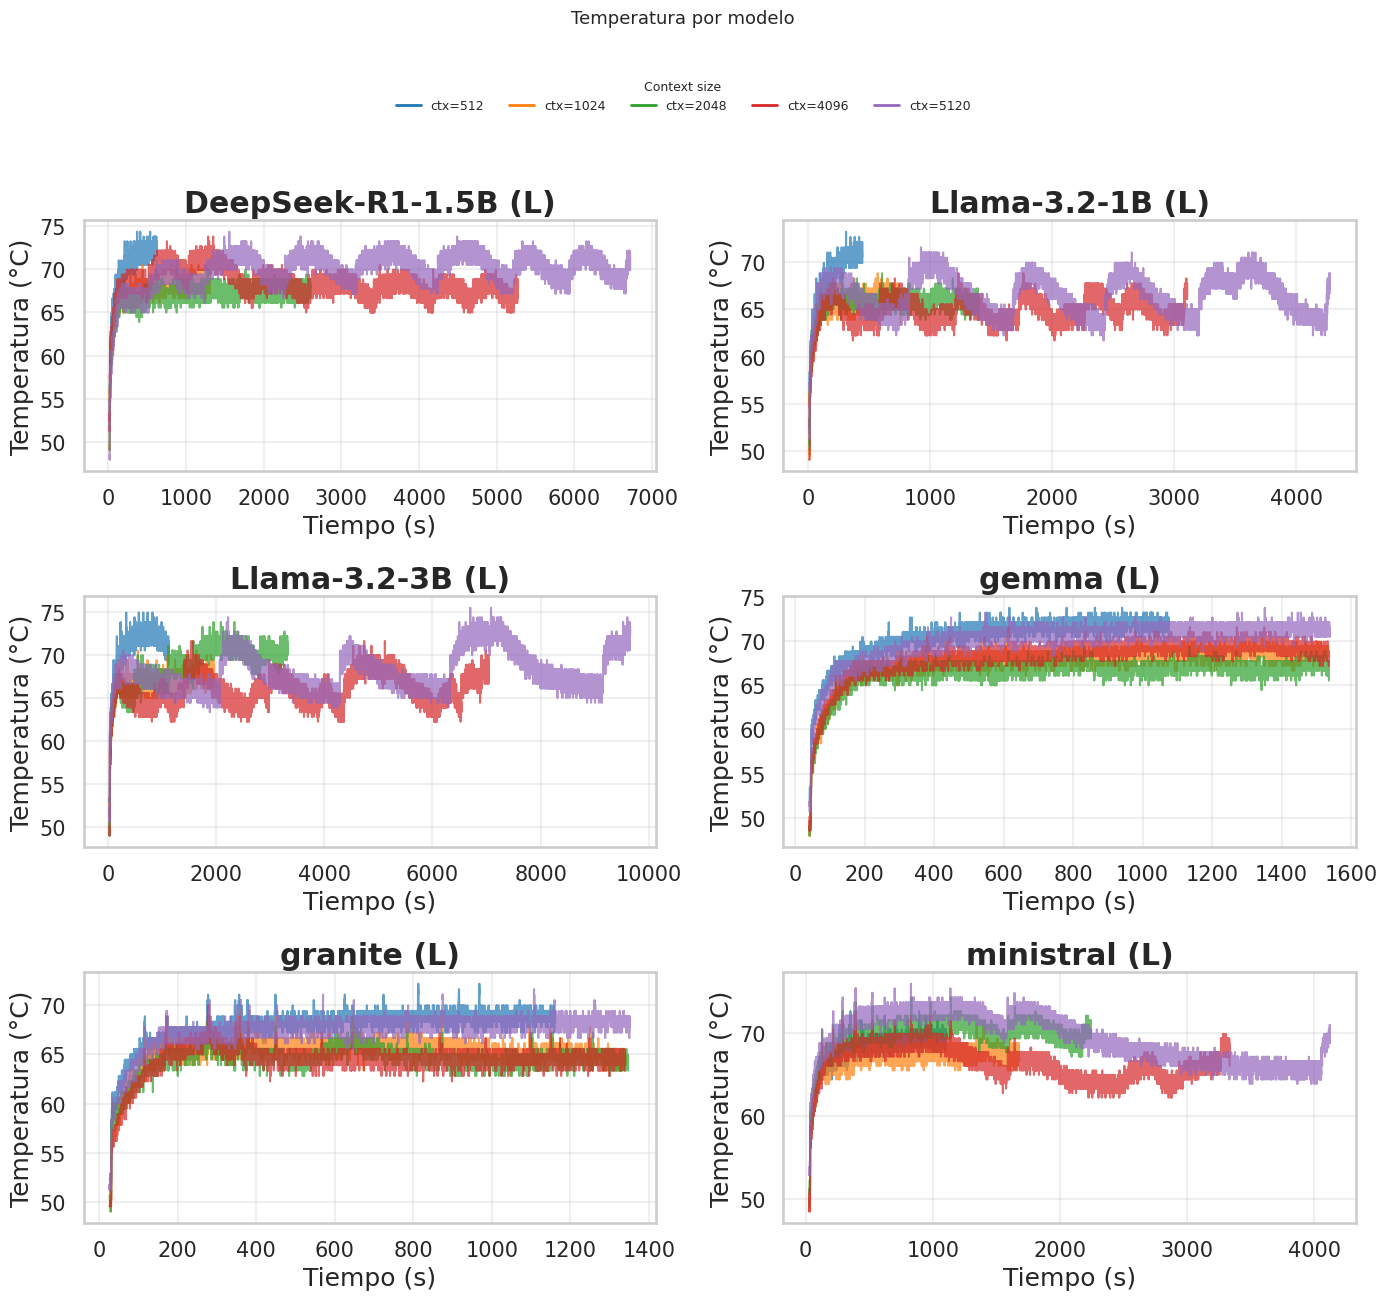

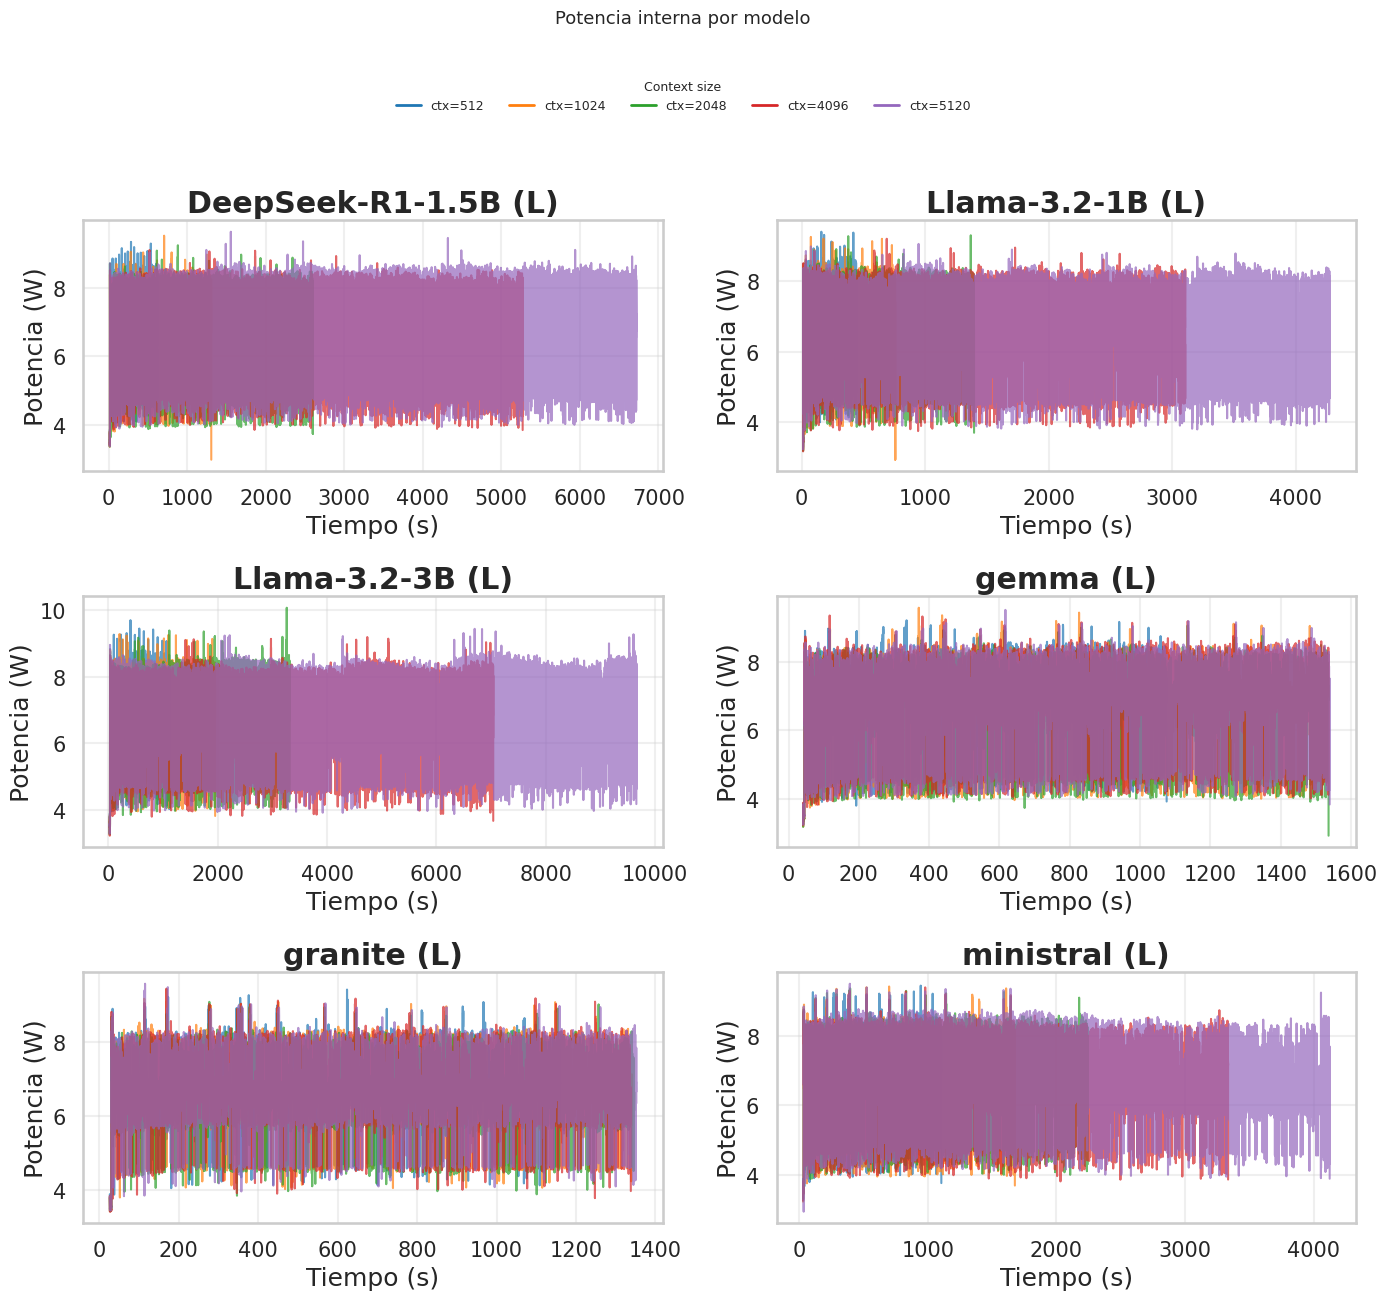

In [8]:
# Timelines de temperatura y potencia — leyenda común en la parte superior
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

_CTX_COLORS = {
    512: "tab:blue", 1024: "tab:orange", 2048: "tab:green",
    4096: "tab:red",  5120: "tab:purple",
}

def _plot_timeline(hw_ex, models, y_col, ylabel, suptitle, hline=None):
    from matplotlib.lines import Line2D as _L2D
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    _all_ctxs = set()
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ctx = int(sub["context_size"].iloc[0]) if "context_size" in sub.columns else 0
            _all_ctxs.add(ctx)
            ax.plot(sub["t_rel_s"].values, sub[y_col].values,
                    alpha=0.7, linewidth=1.5, color=_CTX_COLORS.get(ctx, "gray"))
        if hline is not None:
            ax.axhline(hline, ls="--", color="red", alpha=0.5)
        ax.set_xlabel("Tiempo (s)"); ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight="bold"); ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    # Leyenda común arriba
    _handles = [_L2D([0],[0], color=_CTX_COLORS.get(c,"gray"), lw=2, label=f"ctx={c}")
                for c in sorted(_all_ctxs)]
    fig.legend(handles=_handles, loc="upper center", bbox_to_anchor=(0.5, 1.04),
               ncol=len(_handles), title="Context size", fontsize=9, title_fontsize=9)
    fig.suptitle(suptitle, fontsize=13, y=1.09)
    fig.tight_layout()
    plt.show()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    _plot_timeline(hw_ex, models, "temperature_c", "Temperatura (°C)",
                   "Temperatura por modelo")
    _plot_timeline(hw_ex, models, "internal_power_w", "Potencia (W)",
                   "Potencia interna por modelo")
else:
    print("Sin datos de hardware para timelines")


/tmp/ipykernel_729214/98568102.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_729214/98568102.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


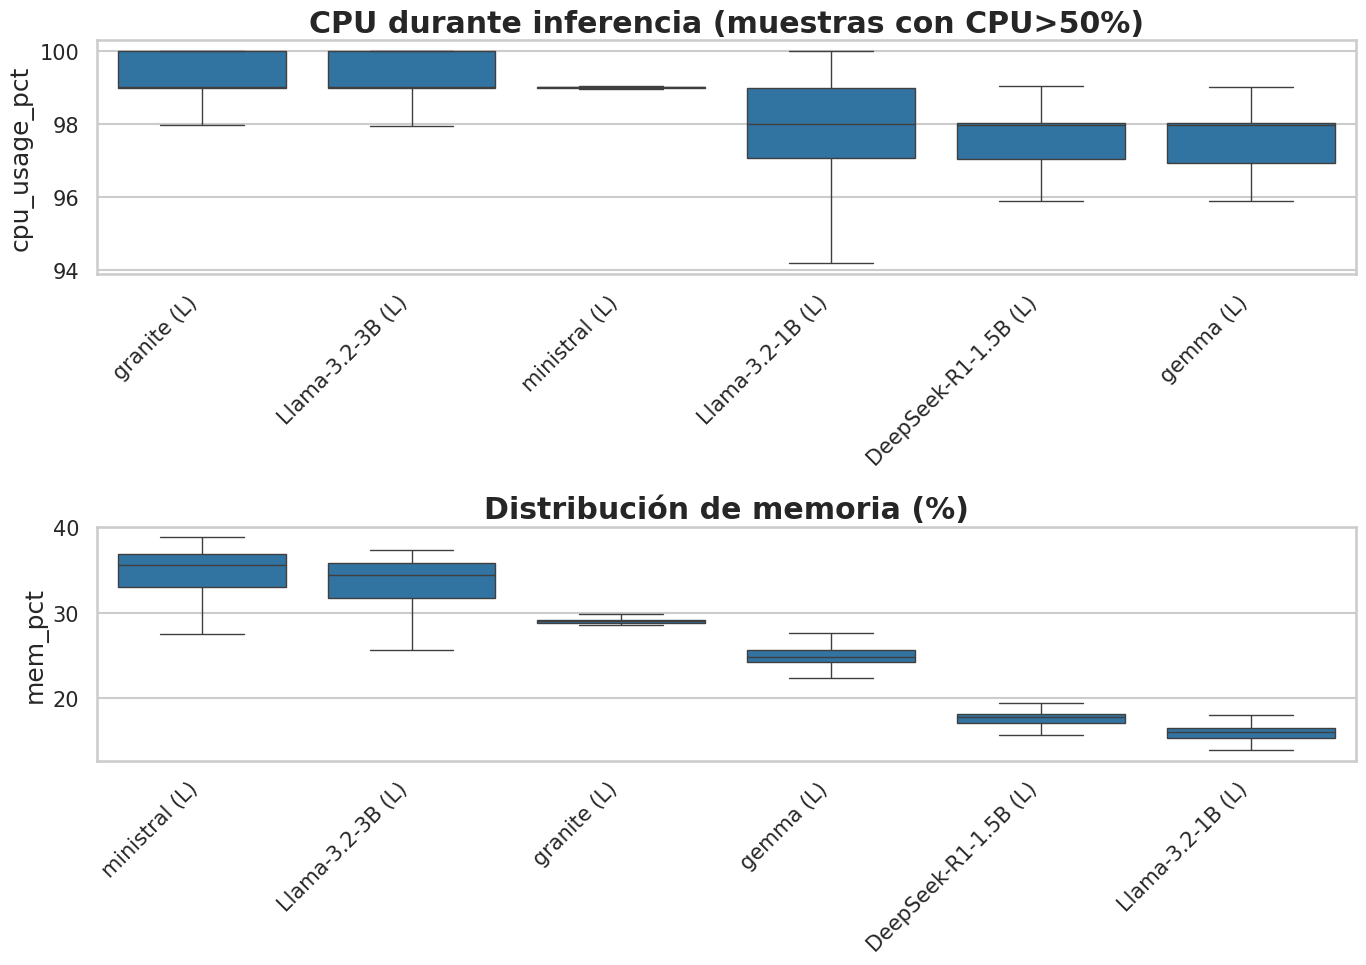

/tmp/ipykernel_729214/98568102.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_729214/98568102.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


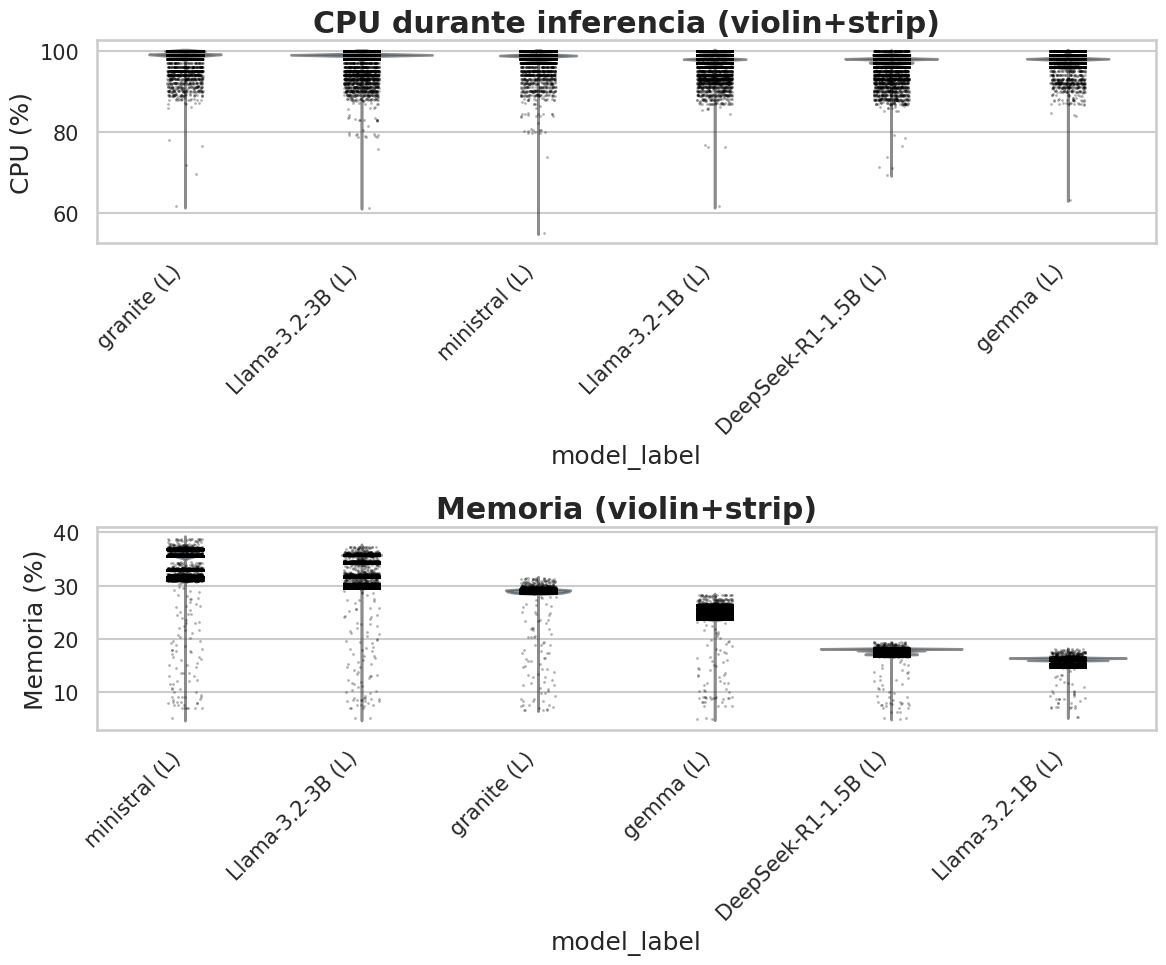

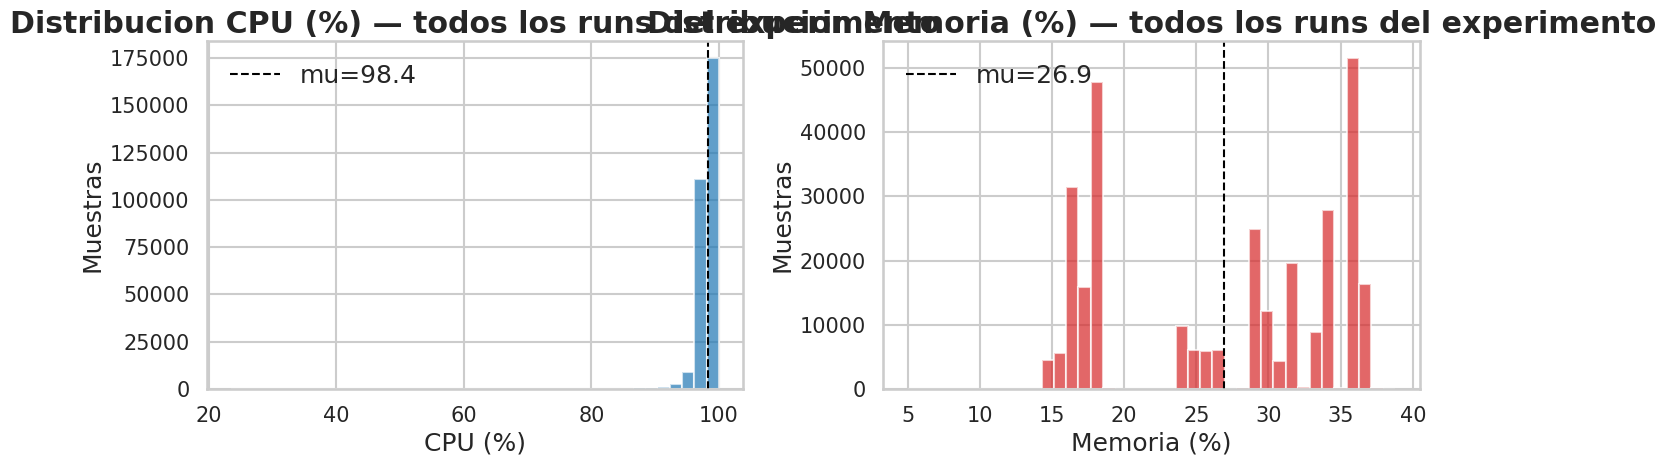

In [9]:
# Sección 5a — Boxplot CPU y Memoria
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=active, x="model_label", y="cpu_usage_pct",
                order=order_cpu, showfliers=False, ax=axes[0])
    axes[0].set_title("CPU durante inferencia (muestras con CPU>50%)")
    axes[0].set_xlabel("")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=hw_ex, x="model_label", y="mem_pct",
                order=order_mem, showfliers=False, ax=axes[1])
    axes[1].set_title("Distribución de memoria (%)")
    axes[1].set_xlabel("")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout()
    plt.show()

    # Sección 5b — Violin + strip
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index
                 if not active.empty else [])
    if len(order_cpu) > 0:
        sns.violinplot(data=active, x="model_label", y="cpu_usage_pct",
                       order=order_cpu, inner=None, alpha=0.6, ax=axes[0])
        sns.stripplot(data=active, x="model_label", y="cpu_usage_pct",
                      order=order_cpu, size=2, alpha=0.3, color="black", ax=axes[0])
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_title("CPU durante inferencia (violin+strip)")
        axes[0].set_ylabel("CPU (%)")
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index)
    sns.violinplot(data=hw_ex, x="model_label", y="mem_pct",
                   order=order_mem, inner=None, alpha=0.6, ax=axes[1])
    sns.stripplot(data=hw_ex, x="model_label", y="mem_pct",
                  order=order_mem, size=2, alpha=0.3, color="black", ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_title("Memoria (violin+strip)")
    axes[1].set_ylabel("Memoria (%)")
    fig.tight_layout()
    plt.show()

    # Sección 5c — Histogramas agregados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (col, xlabel, color) in zip(axes, [
        ("cpu_usage_pct", "CPU (%)", "tab:blue"),
        ("mem_pct", "Memoria (%)", "tab:red"),
    ]):
        active_hist = hw_ex[hw_ex["cpu_usage_pct"] > 10]
        data = active_hist[col].dropna()
        if not data.empty:
            ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
            ax.axvline(data.mean(), color='black', ls='--', lw=1.5,
                       label=f"mu={data.mean():.1f}")
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Muestras")
            ax.set_title(f"Distribucion {xlabel} — todos los runs del experimento")
            ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para distribuciones CPU/Memoria")

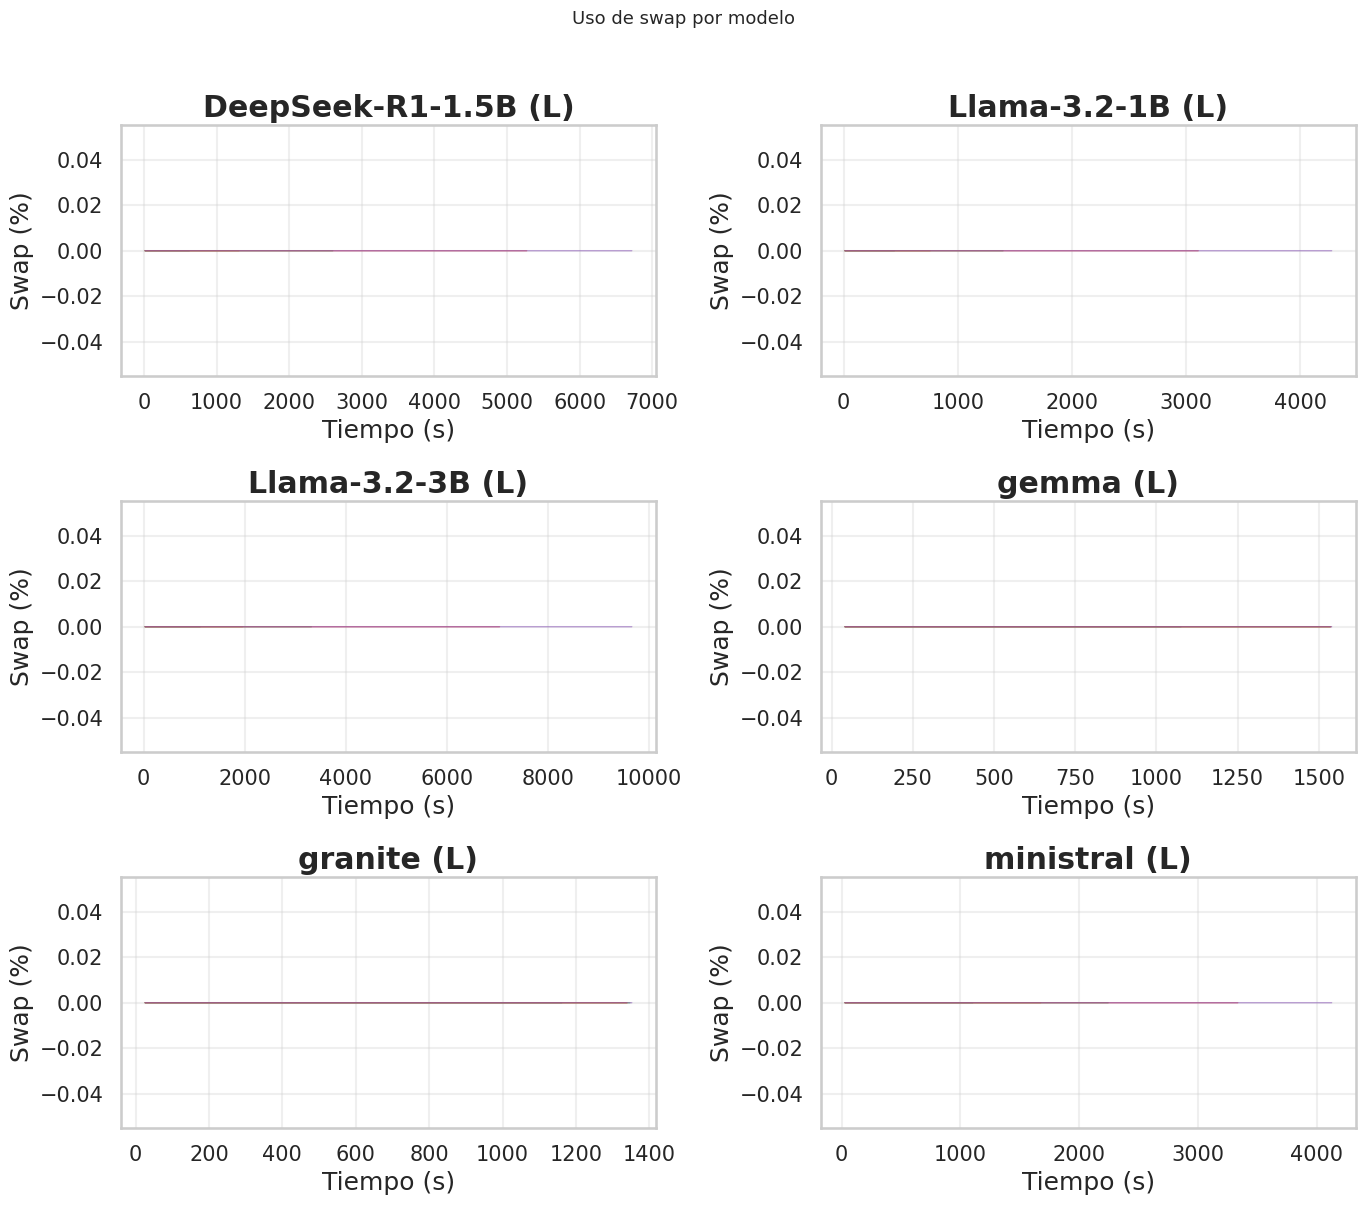

In [10]:
# Swap por modelo (small multiples)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub["swap_pct"].values, alpha=0.6, linewidth=1)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel("Swap (%)")
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle("Uso de swap por modelo", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para swap")

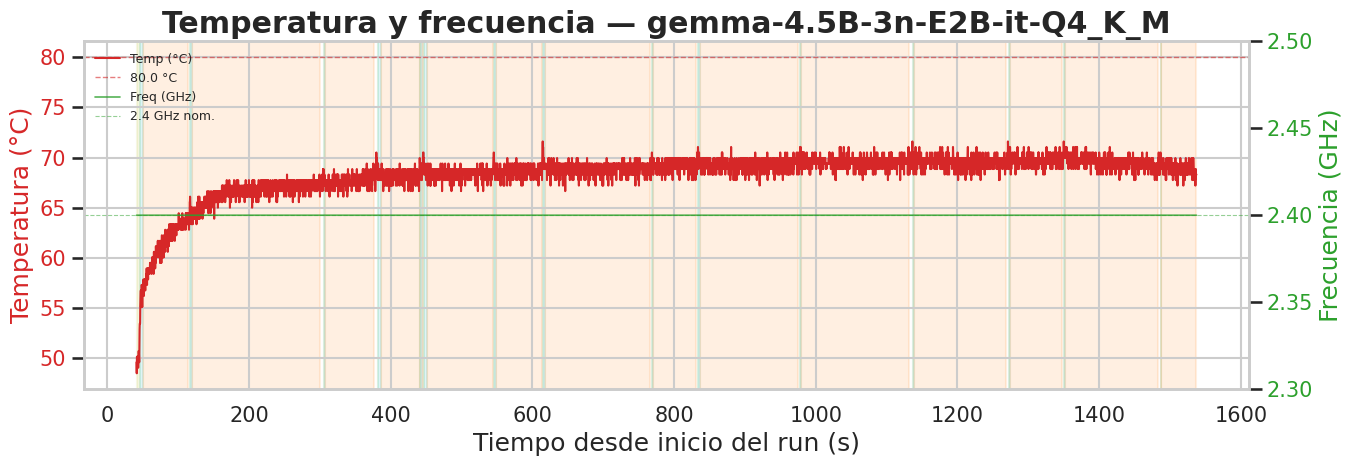

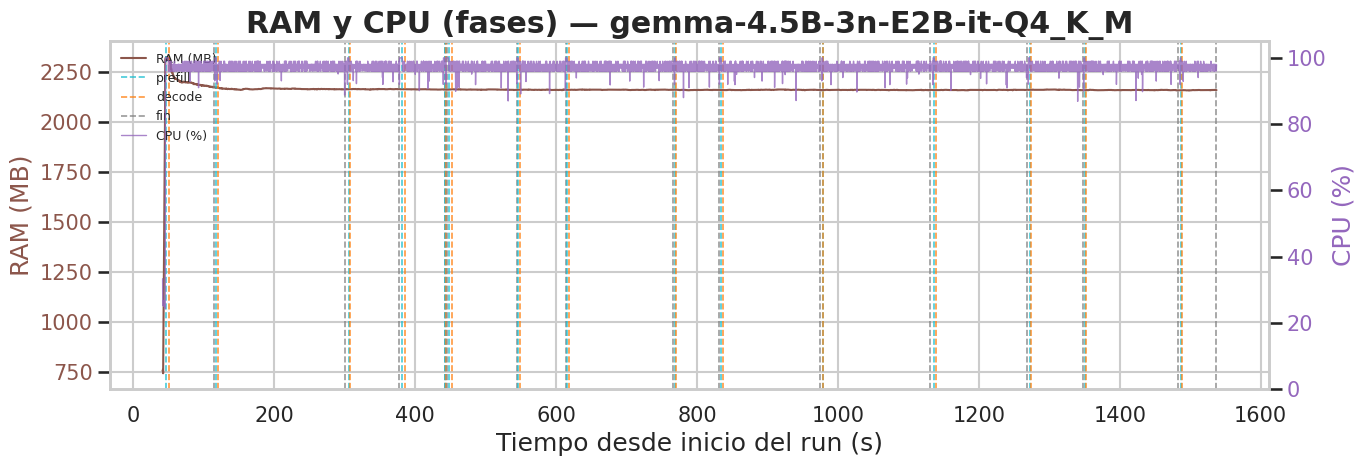

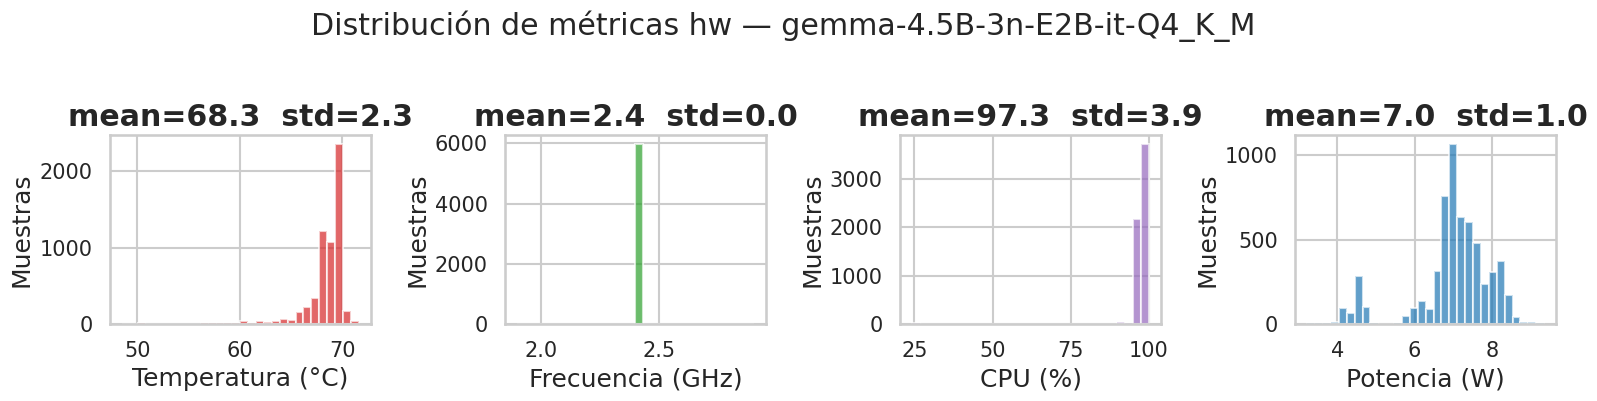

In [11]:
# Análisis detallado de un run representativo (mediana de duración)
from monitorviz.viz import temp_freq_dual, cpu_memory_dual_phases, hw_distributions_panel

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty and len(ex) > 0:
    run_durations = hw_ex.groupby("run_id")["t_rel_s"].max().sort_values()
    median_idx = len(run_durations) // 2
    representative_run_id = run_durations.index[median_idx]
    representative_run = next((r for r in coll.runs if r.run_id == representative_run_id), None)
    if representative_run:
        hw_r = hw_ex[hw_ex["run_id"] == representative_run_id]
        try:
            fig = temp_freq_dual(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"temp_freq_dual: {e}")
        try:
            fig = cpu_memory_dual_phases(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"cpu_memory_dual_phases: {e}")
        try:
            fig = hw_distributions_panel(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"hw_distributions_panel: {e}")
    else:
        print("No se encontro run representativo")
else:
    print("Sin datos para análisis detallado")

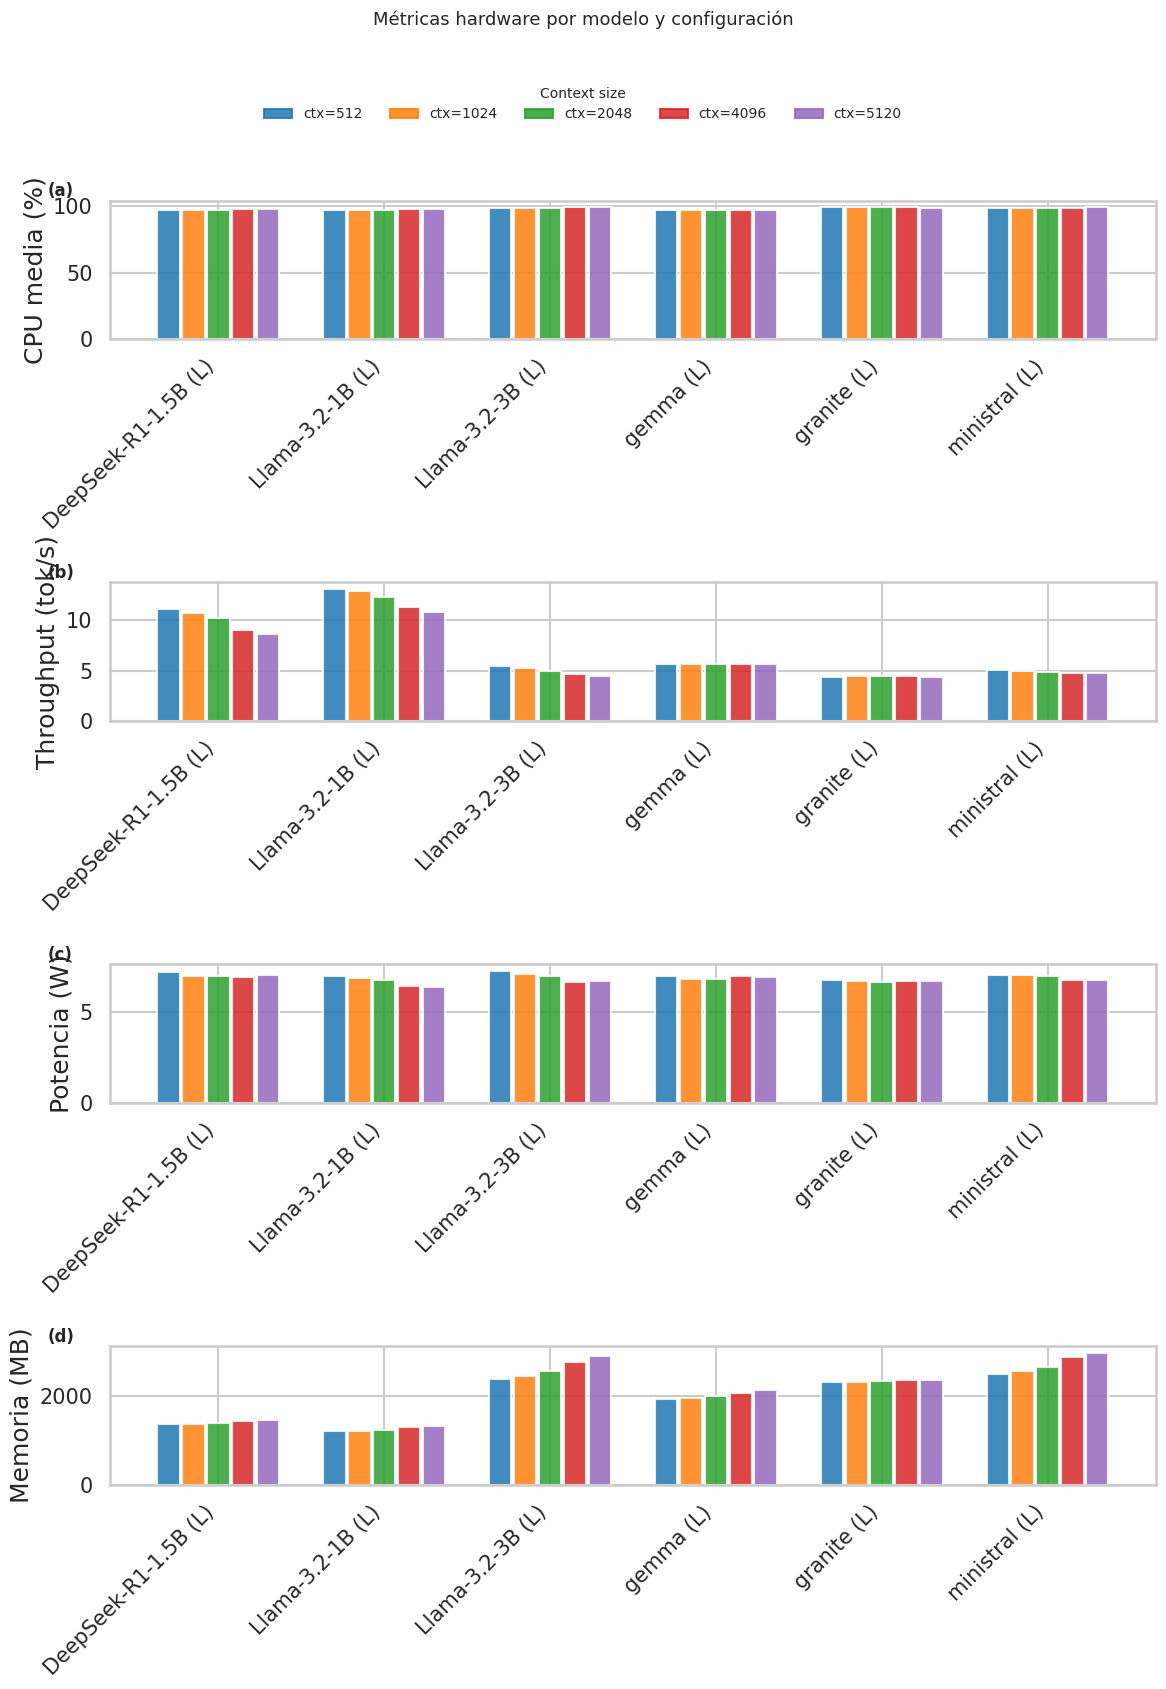

In [12]:
# Grouped bar chart hardware (4 paneles: CPU%, Throughput, Potencia, Memoria)
# Leyenda común arriba — contexto distinguido por color
import re
from matplotlib.patches import Patch

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

hw_summary_rows = []
pm_valid_tmp = (pm_full[
    (pm_full["run_id"].isin(_run_ids)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
] if "run_id" in pm_full.columns else pd.DataFrame())
for _, row in ex.iterrows():
    if "run_id" not in row.index:
        continue
    hw_r = hw_ex[hw_ex["run_id"] == row["run_id"]] if "run_id" in hw_ex.columns else pd.DataFrame()
    pm_r = pm_valid_tmp[pm_valid_tmp["run_id"] == row["run_id"]] if "run_id" in pm_valid_tmp.columns else pd.DataFrame()
    if hw_r.empty:
        continue
    active_r = hw_r[hw_r["cpu_usage_pct"] > 50]
    group_label = str(int(row.get("context_size", 0))) if not pd.isna(row.get("context_size", float("nan"))) else "?"
    hw_summary_rows.append({
        "model": row["model_label"],
        "config": group_label,
        "cpu_pct": active_r["cpu_usage_pct"].mean() if not active_r.empty else float("nan"),
        "tokens_s": pm_r["tokens_per_second"].mean() if not pm_r.empty else float("nan"),
        "power_w": hw_r["internal_power_w"].mean(),
        "mem_mb": hw_r["mem_used_bytes"].mean() / (1024**2) if not hw_r.empty else float("nan"),
    })

if hw_summary_rows:
    hw_summary = pd.DataFrame(hw_summary_rows)
    METRICS = [
        ("cpu_pct",  "CPU media (%)",      "(a)"),
        ("tokens_s", "Throughput (tok/s)", "(b)"),
        ("power_w",  "Potencia (W)",       "(c)"),
        ("mem_mb",   "Memoria (MB)",       "(d)"),
    ]
    models  = sorted(hw_summary["model"].unique())
    configs = sorted(hw_summary["config"].unique(), key=lambda x: int(x) if x.isdigit() else 0)
    x_pos   = np.arange(len(models))
    n_cfg   = len(configs)
    width   = 0.75 / max(n_cfg, 1)
    _CTX_BAR_COLORS = ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown"]

    fig, axes = plt.subplots(len(METRICS), 1, figsize=(12, 4 * len(METRICS)))
    for ax, (col, ylabel, label) in zip(axes, METRICS):
        data = hw_summary.dropna(subset=[col])
        for j, cfg in enumerate(configs):
            color = _CTX_BAR_COLORS[j % len(_CTX_BAR_COLORS)]
            vals = [data[(data["model"] == m) & (data["config"] == cfg)][col].mean()
                    for m in models]
            offset = (j - n_cfg / 2 + 0.5) * width
            ax.bar(x_pos + offset, vals, width * 0.9, color=color, alpha=0.85)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(models, rotation=45, ha="right")
        ax.set_ylabel(ylabel)
        ax.text(-0.06, 1.03, label, transform=ax.transAxes, fontweight="bold", fontsize=12)

    # Leyenda común arriba
    _legend_patches = [Patch(color=_CTX_BAR_COLORS[j % len(_CTX_BAR_COLORS)],
                             label=f"ctx={cfg}", alpha=0.85)
                       for j, cfg in enumerate(configs)]
    fig.legend(handles=_legend_patches, loc="upper center", bbox_to_anchor=(0.5, 1.02),
               ncol=len(_legend_patches), title="Context size", fontsize=10, title_fontsize=10)
    fig.suptitle("Métricas hardware por modelo y configuración", y=1.06, fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para grouped bar chart hardware")


/tmp/ipykernel_729214/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


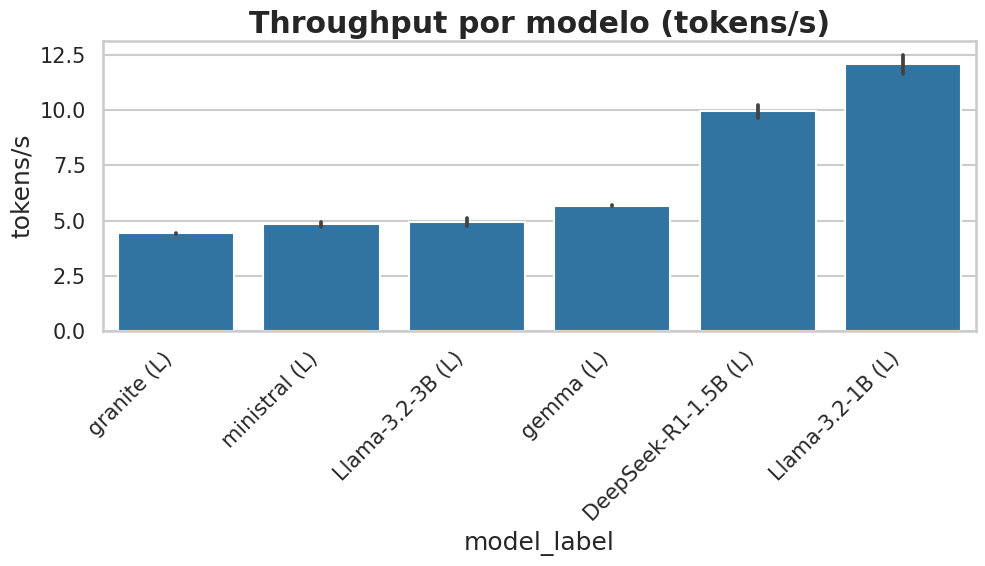

/tmp/ipykernel_729214/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


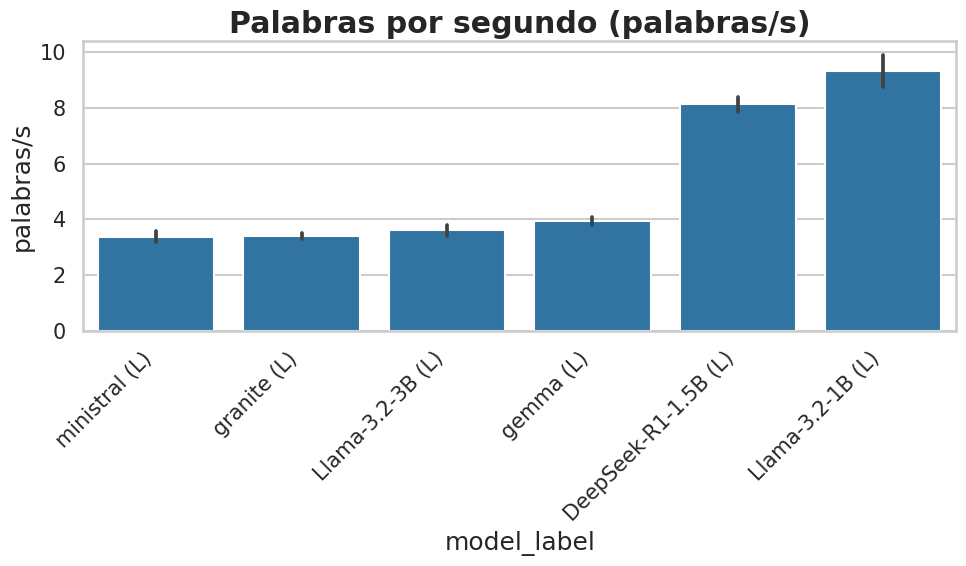

/tmp/ipykernel_729214/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


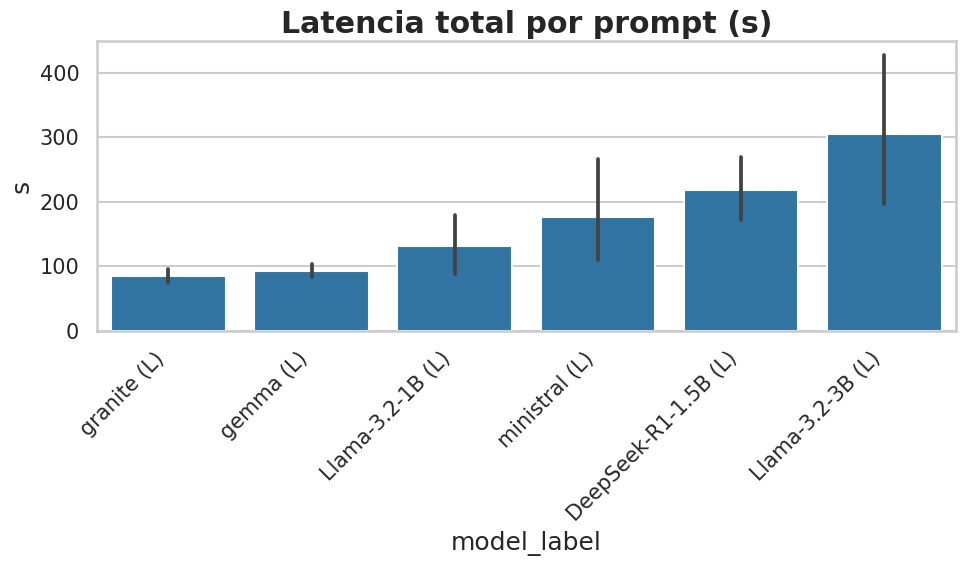

/tmp/ipykernel_729214/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


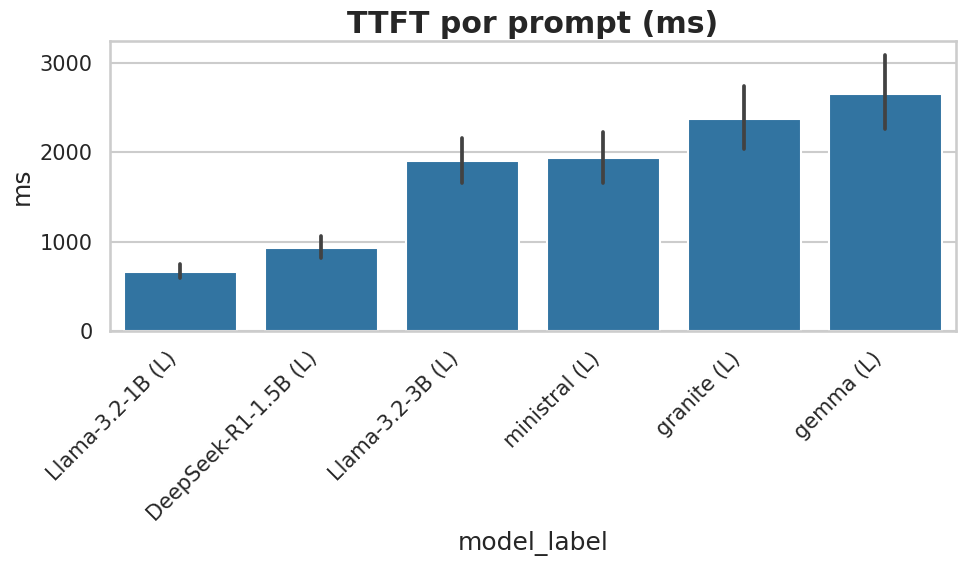

/tmp/ipykernel_729214/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


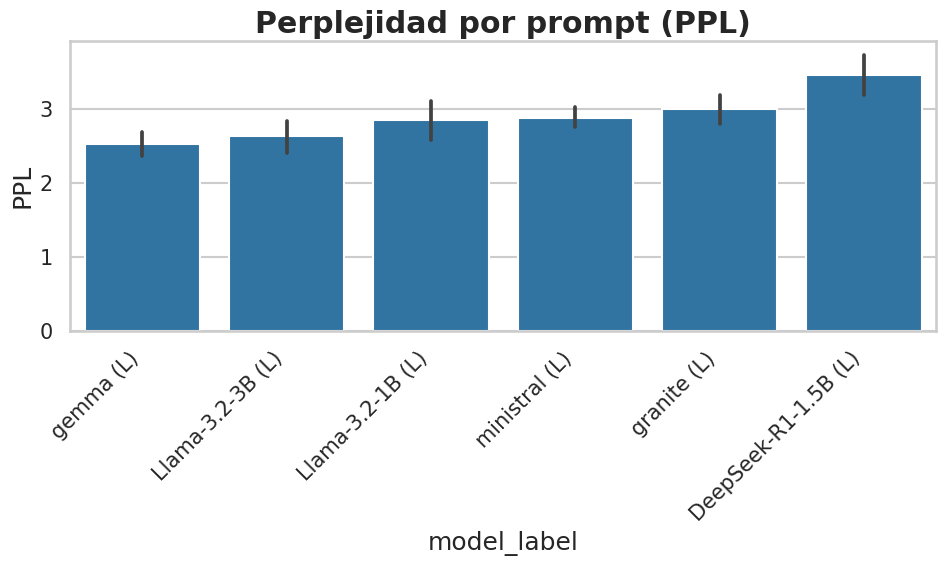

In [13]:
# Métricas de inferencia por modelo
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    _plot_metric(pm_valid, "tokens_per_second", "tokens/s", "Throughput por modelo",
                 unit_label="tokens/s")
    _plot_metric(pm_valid, "words_per_second", "palabras/s", "Palabras por segundo",
                 unit_label="palabras/s")
    _plot_metric(pm_valid, "latency_ms", "ms", "Latencia total por prompt",
                 unit_divisor=1000, unit_label="s")
    _plot_metric(pm_valid, "time_to_first_token_ms", "ms", "TTFT por prompt",
                 unit_label="ms")
    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        _plot_metric(ppl_valid, "perplexity", "", "Perplejidad por prompt",
                     unit_label="PPL")
else:
    print("Sin datos de inferencia")

/tmp/ipykernel_729214/870363815.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


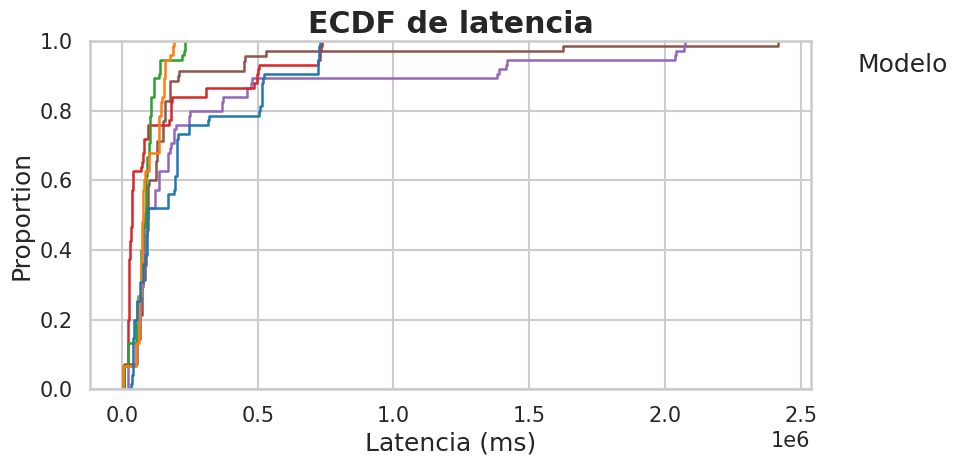

/tmp/ipykernel_729214/870363815.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


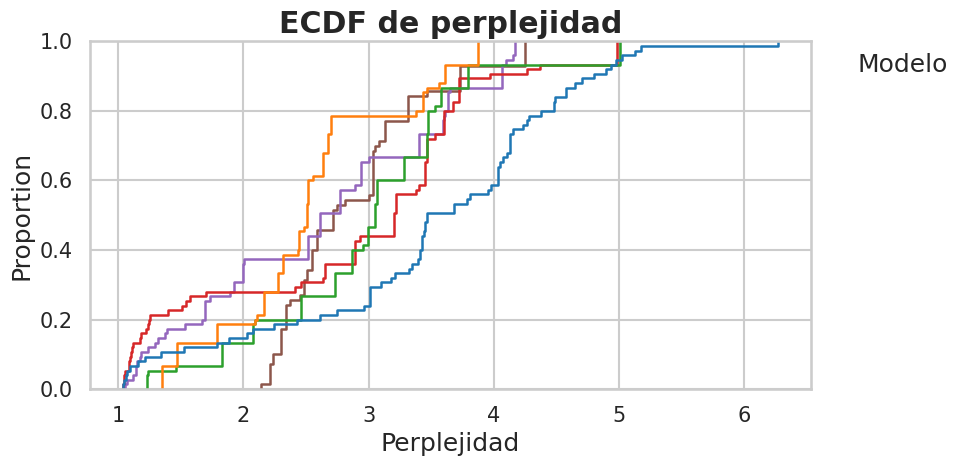

In [14]:
# ECDFs de latencia y perplejidad
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.ecdfplot(data=pm_valid, x="latency_ms", hue="model_label", ax=ax)
    ax.set_title("ECDF de latencia")
    ax.set_xlabel("Latencia (ms)")
    ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    plt.show()

    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.ecdfplot(data=ppl_valid, x="perplexity", hue="model_label", ax=ax)
        ax.set_title("ECDF de perplejidad")
        ax.set_xlabel("Perplejidad")
        ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
else:
    print("Sin datos para ECDFs")

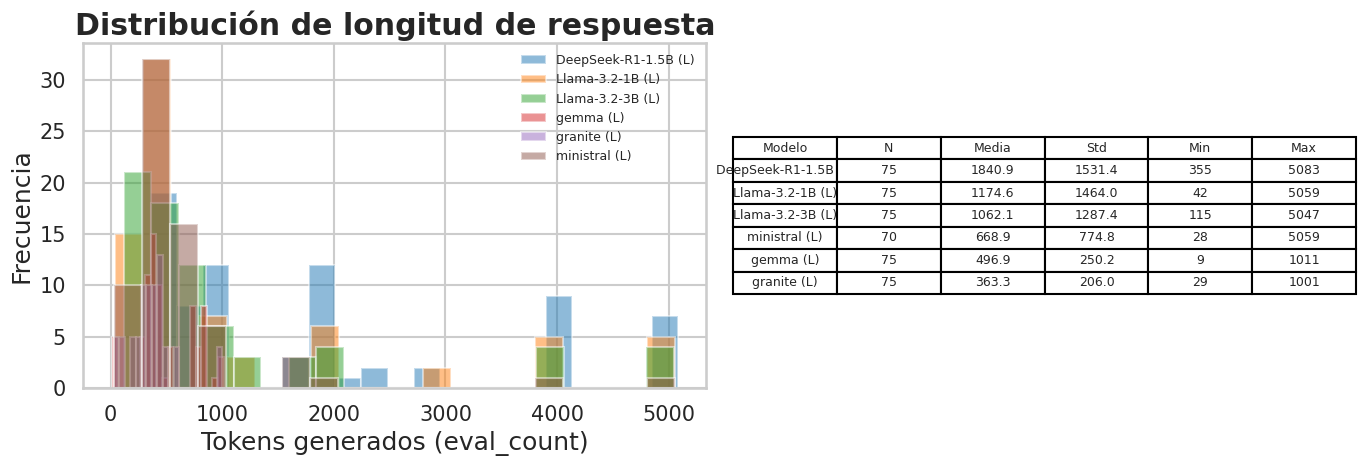

In [15]:
# Distribución de longitud de respuesta
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model in sorted(pm_valid["model_label"].unique()):
        sub = pm_valid[pm_valid["model_label"] == model]
        axes[0].hist(sub["eval_count"], bins=20, alpha=0.5, label=model)
    axes[0].set_xlabel("Tokens generados (eval_count)")
    axes[0].set_ylabel("Frecuencia")
    axes[0].set_title("Distribución de longitud de respuesta")
    axes[0].legend(fontsize=9)
    summary_resp = pm_valid.groupby("model_label")["eval_count"].agg(
        count="count", mean="mean", std="std", min="min", max="max"
    ).round(1).sort_values("mean", ascending=False)
    axes[1].axis("off")
    table_data = [["Modelo", "N", "Media", "Std", "Min", "Max"]]
    for idx, row in summary_resp.iterrows():
        table_data.append([idx, int(row["count"]), f"{row['mean']:.1f}",
                           f"{row['std']:.1f}", f"{row['min']:.0f}", f"{row['max']:.0f}"])
    t = axes[1].table(cellText=table_data, loc="center", cellLoc="center")
    t.auto_set_font_size(False)
    t.set_fontsize(9)
    t.scale(1, 1.5)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para distribución de longitud de respuesta")

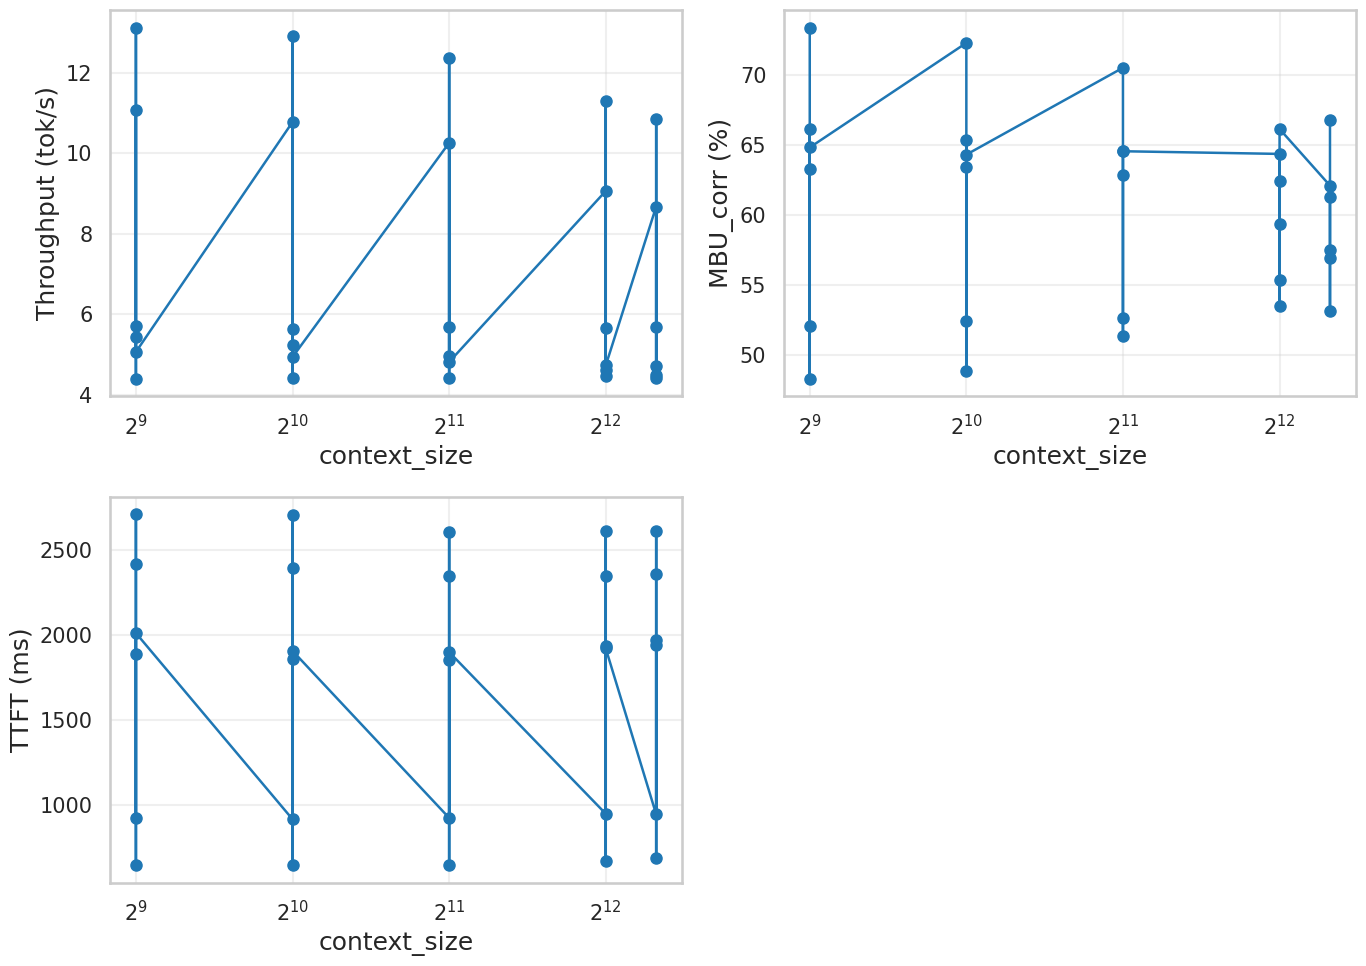

In [16]:
# Análisis específico E2: Context size sensitivity
try:
    from monitorviz.viz import sensitivity_curve
    e2_ok = not ex.empty and "context_size" in ex.columns and ex["context_size"].nunique() >= 2
    if e2_ok:
        fig = sensitivity_curve(ex, param_col="context_size", metrics=[
            ("tokens_per_s_mean", "Throughput (tok/s)"),
            ("mbu_corr", "MBU_corr (%)"),
            ("ttft_ms_mean", "TTFT (ms)"),
        ], log_x=True)
        plt.show()
    else:
        print("Sin datos de context_size")
except Exception as e:
    print(f"Error sensitivity_curve: {e}")

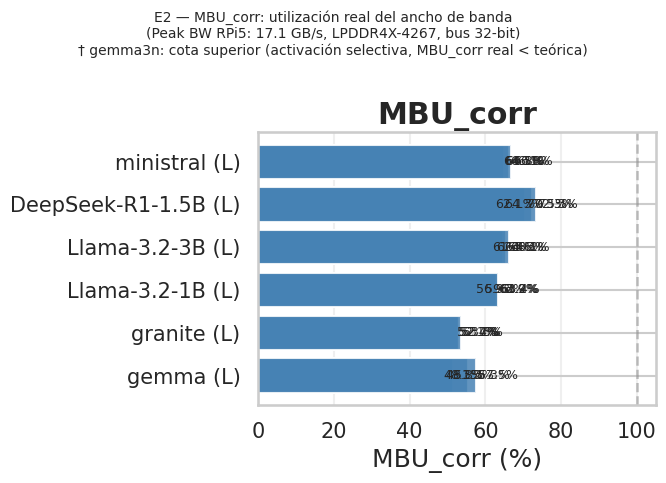

Correcciones aplicadas:


,model_label,mbu_corr,mbu_corr_notes
0,DeepSeek-R1-1.5B (L),73.35,dense
1,gemma (L),48.32,Gemma 3n MatFormer: N_params_act=1.910B (verif...
2,granite (L),52.06,"Granite SSM hybrid: M_state=74.4 MiB, L_ssm=36..."
3,Llama-3.2-1B (L),63.25,dense
4,Llama-3.2-3B (L),66.12,dense
5,ministral (L),64.80,dense


In [17]:
# MBU_corr — Memory Bandwidth Utilization (arquitectura corregida)
from monitorviz.viz.style import TARGET_PEAK_MEMORY_BANDWIDTH_GBs

_mbu_col = "mbu_corr" if "mbu_corr" in ex.columns else (
           "mbu_pct"  if "mbu_pct"  in ex.columns else None)

if _mbu_col is not None:
    mbu_data = ex.dropna(subset=[_mbu_col]).copy()
    if not mbu_data.empty:
        has_fan = "fan" in mbu_data.columns and mbu_data["fan"].nunique() > 1
        fan_groups = (
            [(True, "Con ventilador (FAN)", "steelblue"),
             (False, "Sin ventilador (NOFAN)", "tomato")]
            if has_fan else [(None, "MBU_corr", "steelblue")]
        )
        fig, axes = plt.subplots(1, len(fan_groups),
                                  figsize=(7 * len(fan_groups), 5), sharey=False)
        if len(fan_groups) == 1:
            axes = [axes]
        for ax, (fan_val, lbl, color) in zip(axes, fan_groups):
            sub = (mbu_data[mbu_data["fan"] == fan_val]
                   if fan_val is not None else mbu_data).copy()
            sub = sub.sort_values(_mbu_col)
            if sub.empty:
                ax.set_axis_off(); continue
            ax.barh(sub["model_label"], sub[_mbu_col], color=color, alpha=0.85)
            ax.axvline(100, ls="--", color="gray", alpha=0.5)
            ax.set_xlabel("MBU_corr (%)")
            ax.set_title(lbl)
            ax.grid(True, axis="x", alpha=0.3)
            for bar, val in zip(ax.patches, sub[_mbu_col]):
                ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                        f"{val:.1f}%", va="center", fontsize=9)
        fig.suptitle(
            f"E2 — MBU_corr: utilización real del ancho de banda\n"
            f"(Peak BW RPi5: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s, LPDDR4X-4267, bus 32-bit)\n"
            "† gemma3n: cota superior (activación selectiva, MBU_corr real < teórica)",
            fontsize=10)
        plt.tight_layout()
        plt.show()
        if "mbu_corr_notes" in mbu_data.columns:
            notes = (mbu_data[["model_label","mbu_corr","mbu_corr_notes"]]
                     .drop_duplicates("model_label").round(2))
            print("Correcciones aplicadas:")
            display(notes)
else:
    print("mbu_corr no disponible en este experimento.")


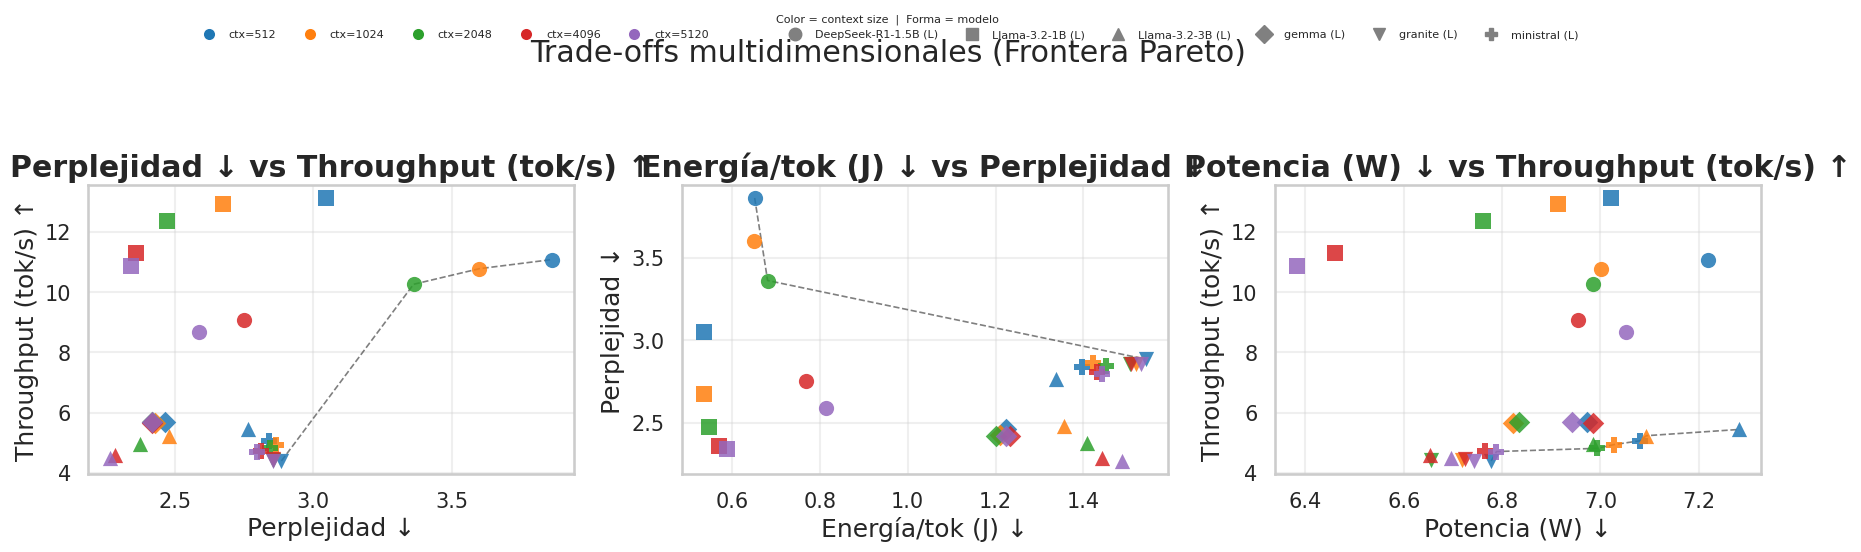

In [18]:
# Trade-offs multidimensionales — Frontera de Pareto
# Formas = modelo, colores = context_size, leyenda común arriba
try:
    from matplotlib.lines import Line2D as _L2D

    _pareto_pairs = [
        ("perplexity_geomean", "tokens_per_s_mean", "Perplejidad ↓", "Throughput (tok/s) ↑", True, False),
        ("energy_per_token_j", "perplexity_geomean", "Energía/tok (J) ↓", "Perplejidad ↓", True, True),
        ("power_mean_w", "tokens_per_s_mean", "Potencia (W) ↓", "Throughput (tok/s) ↑", True, False),
    ]
    valid_pairs = [(p,q,xl,yl,mx,my) for p,q,xl,yl,mx,my in _pareto_pairs
                   if p in ex.columns and q in ex.columns]

    if not valid_pairs or ex.empty:
        print("Columnas insuficientes para Pareto")
    else:
        _CTXS_P  = sorted(ex["context_size"].dropna().unique()) if "context_size" in ex.columns else []
        _CTX_PAL_P = dict(zip([int(c) for c in _CTXS_P],
                               ["tab:blue","tab:orange","tab:green","tab:red","tab:purple"]))
        _MODELS_P = sorted(ex["model_label"].unique())
        _MK_POOL_P = ["o","s","^","D","v","P","X"]
        _MOD_MK_P  = {m: _MK_POOL_P[i % len(_MK_POOL_P)] for i, m in enumerate(_MODELS_P)}

        def _pareto_mask(df, x_col, y_col, minimize_x, minimize_y):
            data = df[[x_col, y_col]].values.copy().astype(float)
            if not minimize_x: data[:,0] = -data[:,0]
            if not minimize_y: data[:,1] = -data[:,1]
            is_p = np.ones(len(data), dtype=bool)
            for i in range(len(data)):
                if not is_p[i]: continue
                dominated = np.all(data <= data[i], axis=1) & np.any(data < data[i], axis=1)
                dominated[i] = False
                is_p[dominated] = False
            return is_p

        fig, axes = plt.subplots(1, len(valid_pairs), figsize=(6 * len(valid_pairs), 5))
        if len(valid_pairs) == 1: axes = [axes]

        for ax, (x_col, y_col, xl, yl, mx, my) in zip(axes, valid_pairs):
            d = ex.dropna(subset=[x_col, y_col]).reset_index(drop=True)
            for idx, row in d.iterrows():
                ctx = int(row["context_size"]) if "context_size" in row.index else 0
                ax.scatter(row[x_col], row[y_col],
                           color=_CTX_PAL_P.get(ctx, "gray"),
                           marker=_MOD_MK_P.get(row["model_label"], "o"),
                           s=120, zorder=3, alpha=0.85, linewidths=0)
            try:
                pm = _pareto_mask(d, x_col, y_col, mx, my)
                pf = d[pm].sort_values(x_col)
                ax.plot(pf[x_col], pf[y_col], "k--", lw=1.2, alpha=0.5, zorder=2)
            except Exception: pass
            ax.set_xlabel(xl); ax.set_ylabel(yl)
            ax.set_title(f"{xl} vs {yl}"); ax.grid(True, alpha=0.3)

        # Leyenda común arriba: colores=contexto | formas=modelo
        _ch = [_L2D([0],[0], marker="o", color="w",
                    markerfacecolor=_CTX_PAL_P.get(int(c),"gray"),
                    markersize=9, label=f"ctx={int(c)}") for c in _CTXS_P]
        _sep = _L2D([0],[0], color="none", label="")
        _mh  = [_L2D([0],[0], marker=_MOD_MK_P[m], color="gray",
                     markersize=9, linestyle="None", label=m) for m in _MODELS_P]
        fig.legend(handles=_ch + [_sep] + _mh,
                   loc="upper center", bbox_to_anchor=(0.5, 1.13),
                   ncol=len(_ch) + 1 + len(_mh), fontsize=8, title_fontsize=8,
                   title="Color = context size  |  Forma = modelo")
        fig.suptitle("Trade-offs multidimensionales (Frontera Pareto)", y=1.06)
        fig.tight_layout()
        plt.show()

except Exception:
    import traceback; traceback.print_exc()


In [19]:
# Desglose de fases (si hay datos)
try:
    from monitorviz.viz import phase_breakdown_stacked
    _run_ids_15 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    pm_valid = (pm_full[
        (pm_full["run_id"].isin(_run_ids_15)) &
        (~pm_full["is_empty_generation"]) &
        (pm_full["latency_ms"] > 0)
    ] if "run_id" in pm_full.columns else pd.DataFrame())
    if not pm_valid.empty and "phase_prompt_s" in pm_valid.columns:
        fig = phase_breakdown_stacked(ex, normalized=True)
        plt.show()
        fig = phase_breakdown_stacked(ex, normalized=False)
        plt.show()
    else:
        print("Sin datos de fases")
except Exception as e:
    print(f"Error en phase_breakdown: {e}")

Sin datos de fases


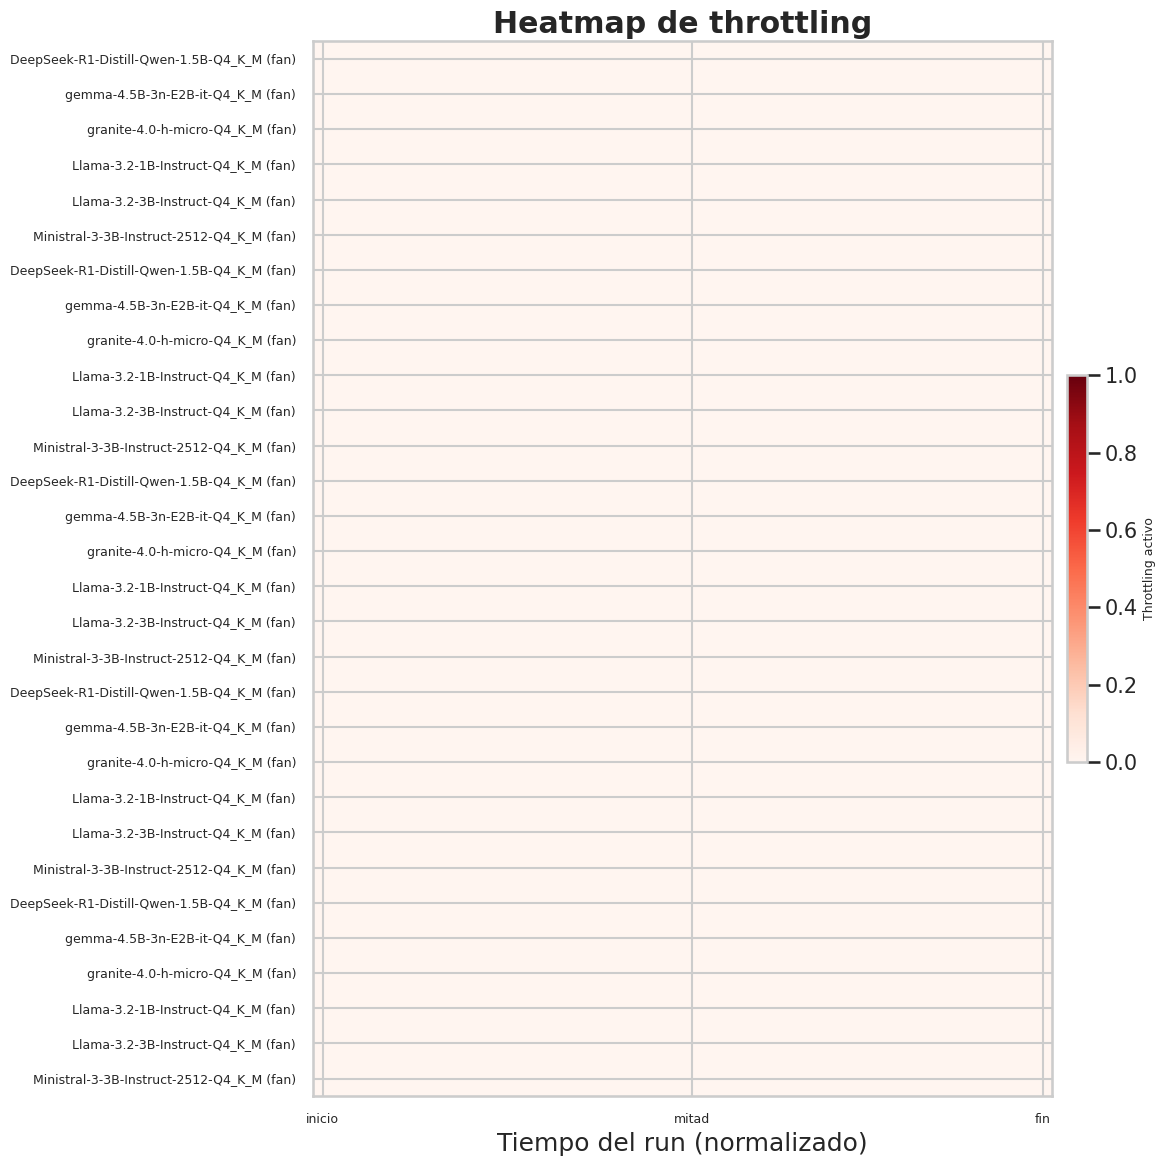

In [20]:
# Throttling heatmap
try:
    from monitorviz.viz import throttling_heatmap
    _run_ids_16 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    hw_ex = hw_full[hw_full["run_id"].isin(_run_ids_16)] if "run_id" in hw_full.columns else pd.DataFrame()
    runs_ex = [r for r in coll.runs if r.run_id in _run_ids_16]
    if hw_ex.empty or not runs_ex:
        print("Sin datos de hardware para heatmap de throttling")
    else:
        fig = throttling_heatmap(hw_ex, runs_ex, bins=40,
                                 title="Heatmap de throttling")
        plt.show()
except Exception as e:
    print(f"Error en throttling_heatmap: {e}")

###Eficiencia computacional: trabajo CPU efectivo

- **W_CPU (core·s)**: integra `(f(t)/f_nom) x (CPU(t)/100) x N_cores x dt`
- **eta_CPU**: W_CPU / (N_cores x T), rango [0,1]
- **W_token (core·s/token)**: trabajo CPU por token generado

/tmp/ipykernel_729214/3033274886.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


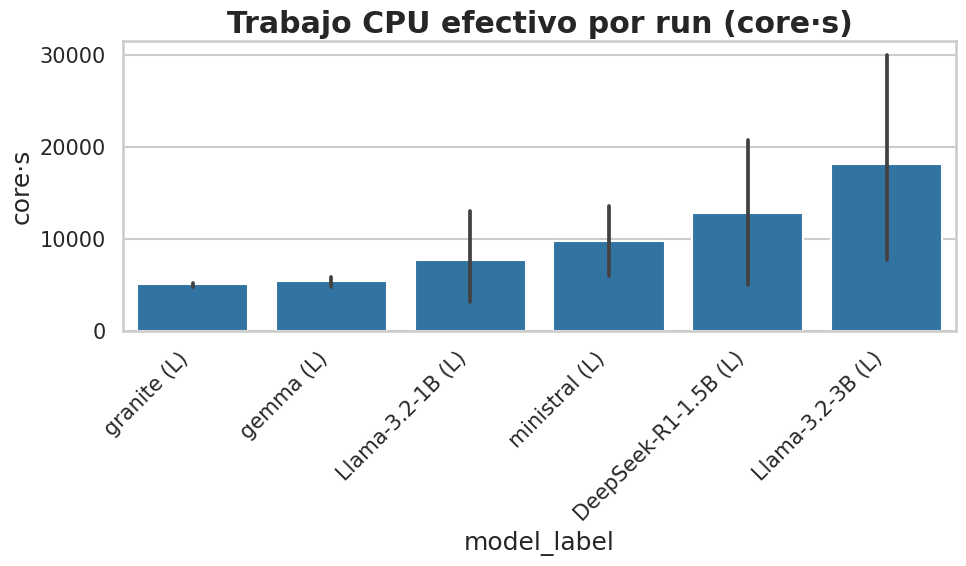

/tmp/ipykernel_729214/3033274886.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


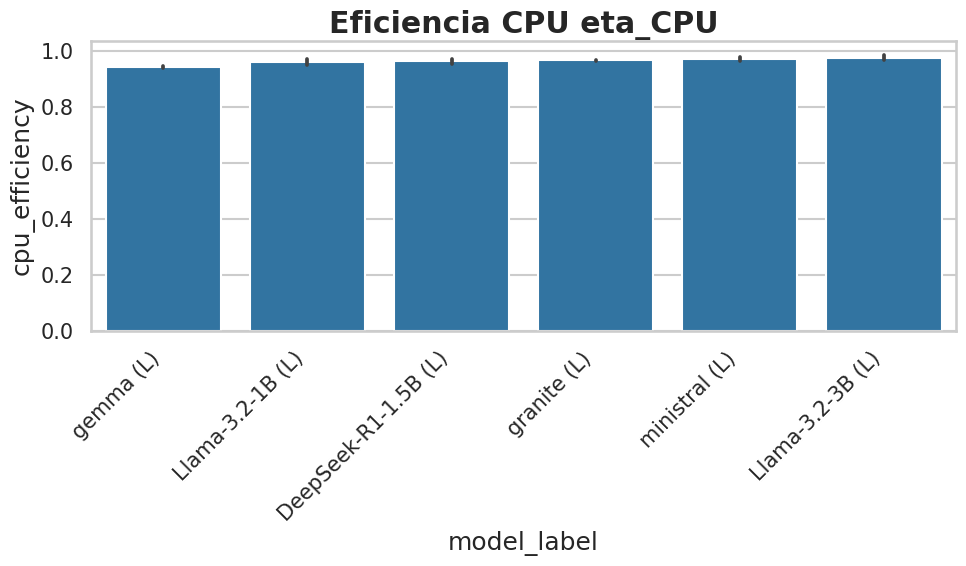

/tmp/ipykernel_729214/3033274886.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


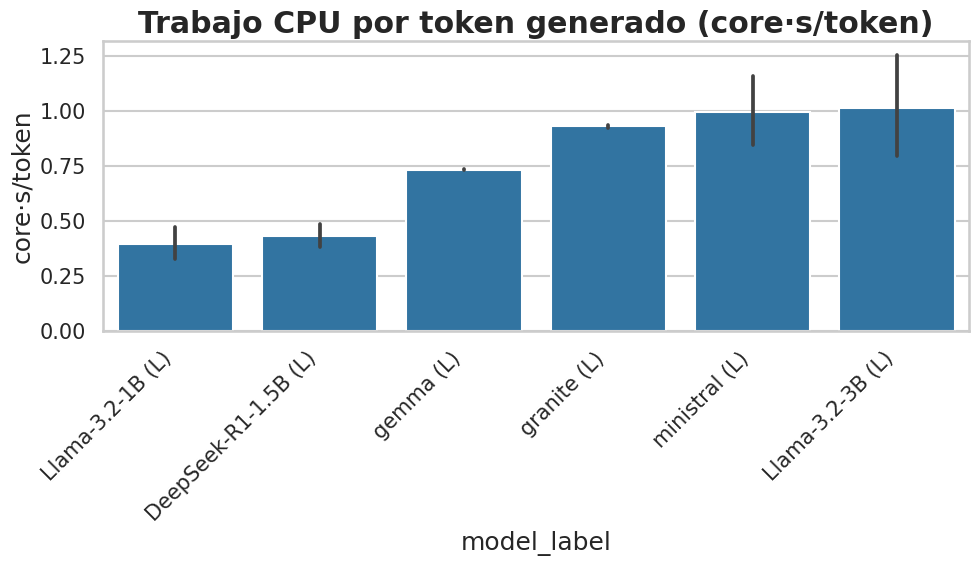

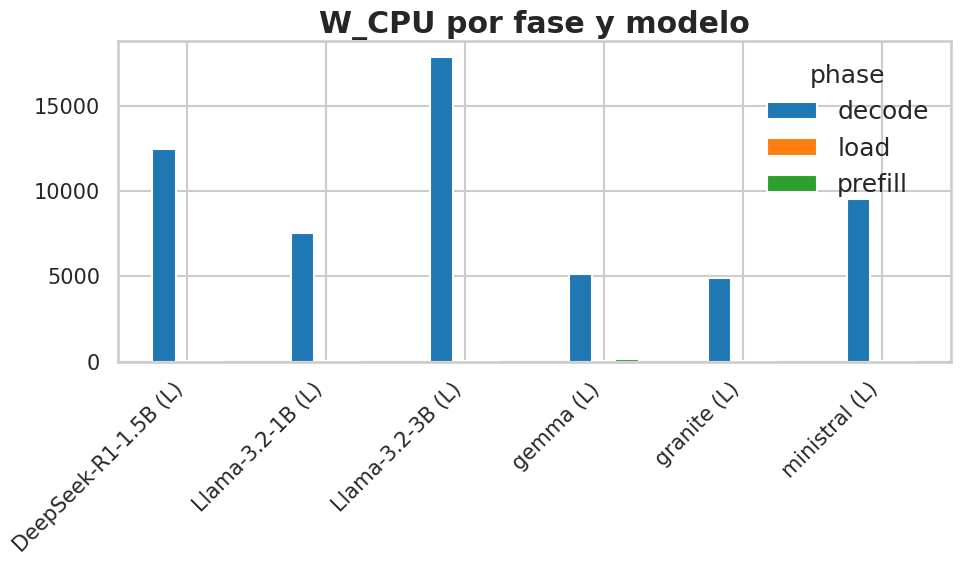

/tmp/ipykernel_729214/3033274886.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


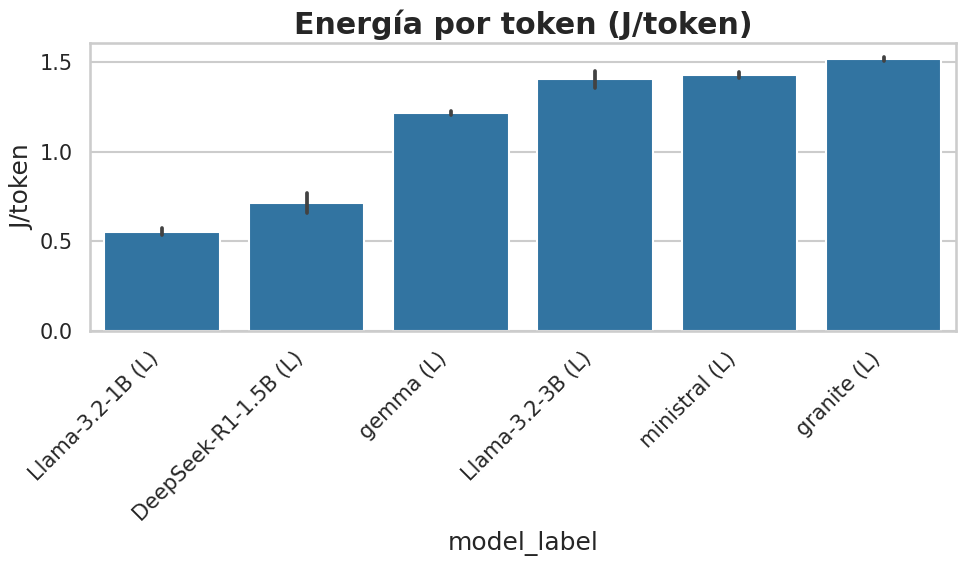

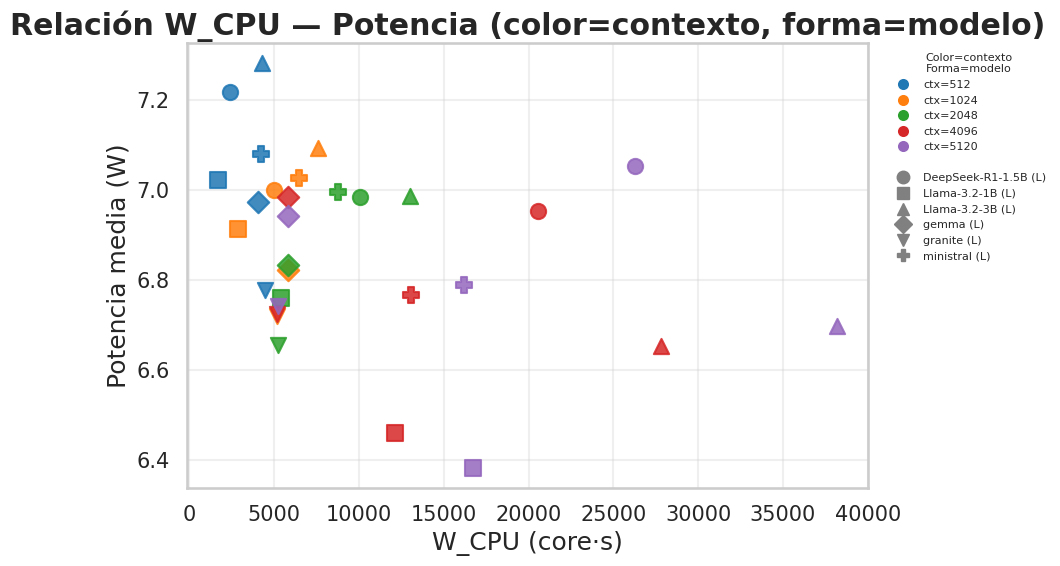

In [21]:
# Eficiencia computacional y energética
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

for col, ylabel, title in [
    ("cpu_work_core_s", "core·s", "Trabajo CPU efectivo por run"),
    ("cpu_efficiency",  "",       "Eficiencia CPU eta_CPU"),
    ("cpu_work_per_token", "core·s/token", "Trabajo CPU por token generado"),
]:
    if col in ex.columns:
        _plot_metric(ex, col, ylabel=ylabel, title=title, unit_label=ylabel)

# Desglose por fases
try:
    phase_df = coll.cpu_work_by_phase_df() if hasattr(coll, "cpu_work_by_phase_df") else pd.DataFrame()
    phase_df_ex = phase_df[phase_df["run_id"].isin(ex["run_id"])] if not phase_df.empty else pd.DataFrame()
    if not phase_df_ex.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        phase_df_ex.groupby(["model_label", "phase"])["cpu_work_core_s"].mean().unstack().plot(
            kind="bar", ax=ax, rot=45)
        ax.set_title("W_CPU por fase y modelo")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        fig.tight_layout()
        plt.show()
except Exception as e:
    print(f"cpu_work_by_phase_df: {e}")

# Energía por token
if "energy_per_token_j" in ex.columns:
    _plot_metric(ex, "energy_per_token_j", "J/token", "Energía por token", unit_label="J/token")

# Scatterplot CPU vs Potencia — colores=contexto, formas=modelo
if "cpu_work_core_s" in ex.columns and "power_mean_w" in ex.columns:
    from matplotlib.lines import Line2D as _L2D
    valid_data = ex.dropna(subset=["cpu_work_core_s", "power_mean_w"]).copy()
    if not valid_data.empty:
        _CTXS2   = sorted(valid_data["context_size"].dropna().unique()) if "context_size" in valid_data.columns else []
        _CTX_PAL2 = dict(zip([int(c) for c in _CTXS2],
                              ["tab:blue","tab:orange","tab:green","tab:red","tab:purple"]))
        _MODELS2 = sorted(valid_data["model_label"].unique())
        _MK_POOL2 = ["o","s","^","D","v","P","X"]
        _MOD_MK2  = {m: _MK_POOL2[i % len(_MK_POOL2)] for i, m in enumerate(_MODELS2)}

        fig, ax = plt.subplots(figsize=(10, 6))
        for _, row in valid_data.iterrows():
            ctx = int(row["context_size"]) if "context_size" in row.index and row["context_size"]==row["context_size"] else 0
            ax.scatter(row["cpu_work_core_s"], row["power_mean_w"],
                       color=_CTX_PAL2.get(ctx, "gray"),
                       marker=_MOD_MK2.get(row["model_label"], "o"),
                       s=120, zorder=3, alpha=0.85)
        ax.set_xlabel("W_CPU (core·s)")
        ax.set_ylabel("Potencia media (W)")
        ax.set_title("Relación W_CPU — Potencia (color=contexto, forma=modelo)")
        ax.grid(True, alpha=0.3)

        _ch = [_L2D([0],[0], marker="o", color="w", markerfacecolor=_CTX_PAL2.get(c,"gray"),
                    markersize=9, label=f"ctx={c}") for c in _CTXS2]
        _mh = [_L2D([0],[0], marker=_MOD_MK2[m], color="gray", markersize=9,
                    linestyle="None", label=m) for m in _MODELS2]
        ax.legend(handles=_ch + [_L2D([0],[0],color="none",label="")] + _mh,
                  bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8,
                  title="Color=contexto\nForma=modelo", title_fontsize=8)
        fig.tight_layout()
        plt.show()


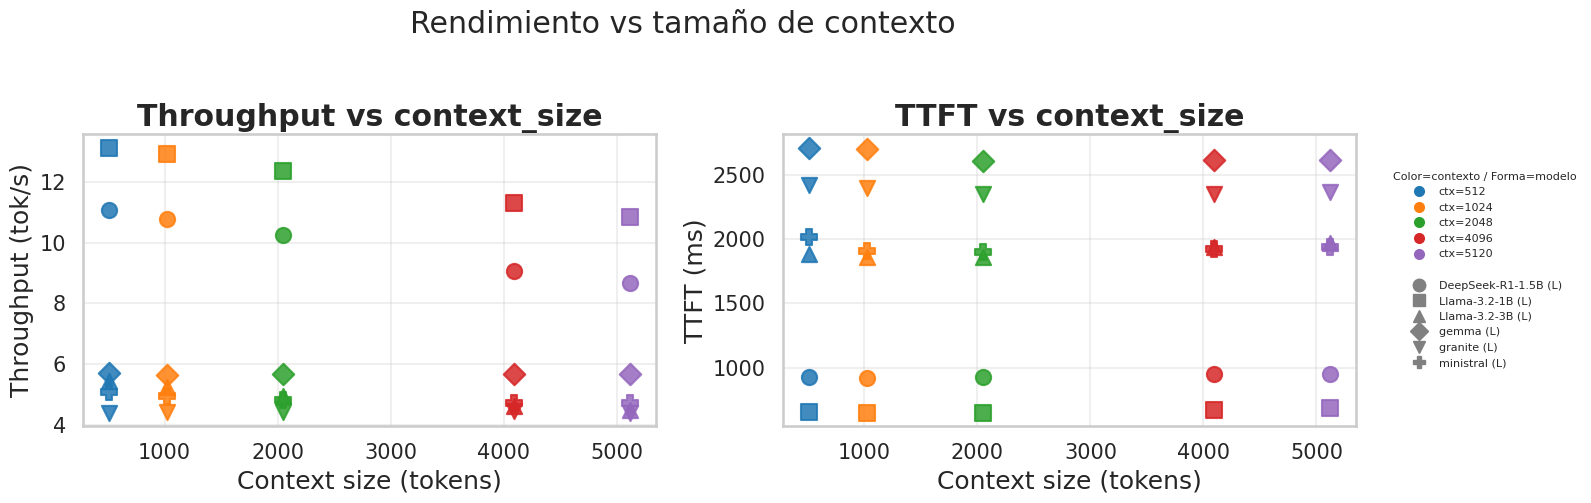

In [22]:
# Rendimiento vs context_size (E2) — colores=contexto, formas=modelo
if "context_size" in ex.columns and ex["context_size"].notna().any():
    from matplotlib.lines import Line2D as _L2D
    ctx_data = ex.dropna(subset=["context_size"]).copy()
    ctx_data["_ctx_str"] = ctx_data["context_size"].astype(int).astype(str)

    _CTXS = sorted(ctx_data["_ctx_str"].unique(), key=lambda x: int(x))
    _MODELS = sorted(ctx_data["model_label"].unique())
    _CTX_PAL = dict(zip(_CTXS, ["tab:blue","tab:orange","tab:green","tab:red","tab:purple"]))
    _MK_POOL = ["o", "s", "^", "D", "v", "P", "X"]
    _MOD_MK  = {m: _MK_POOL[i % len(_MK_POOL)] for i, m in enumerate(_MODELS)}

    def _scatter_ctx(ax, data, x_col, y_col, xlabel, ylabel, title):
        for _, row in data.iterrows():
            ax.scatter(row[x_col], row[y_col],
                       color=_CTX_PAL.get(str(int(row["context_size"])), "gray"),
                       marker=_MOD_MK.get(row["model_label"], "o"),
                       s=120, zorder=3, alpha=0.85)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.grid(True, alpha=0.3)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    _scatter_ctx(axes[0], ctx_data, "context_size", "tokens_per_s_mean",
                 "Context size (tokens)", "Throughput (tok/s)", "Throughput vs context_size")
    _scatter_ctx(axes[1], ctx_data, "context_size", "ttft_ms_mean",
                 "Context size (tokens)", "TTFT (ms)", "TTFT vs context_size")

    # Leyendas compartidas externas
    _ctx_handles  = [_L2D([0],[0], marker="o", color="w", markerfacecolor=c,
                           markersize=9, label=f"ctx={k}") for k, c in _CTX_PAL.items()]
    _mod_handles  = [_L2D([0],[0], marker=_MOD_MK[m], color="gray",
                           markersize=9, linestyle="None", label=m) for m in _MODELS]
    fig.legend(handles=_ctx_handles + [_L2D([0],[0],color="none",label="")] + _mod_handles,
               loc="center left", bbox_to_anchor=(1.0, 0.5),
               title="Color=contexto / Forma=modelo", fontsize=8, title_fontsize=8)
    fig.suptitle("Rendimiento vs tamaño de contexto", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos context_size para scatter")


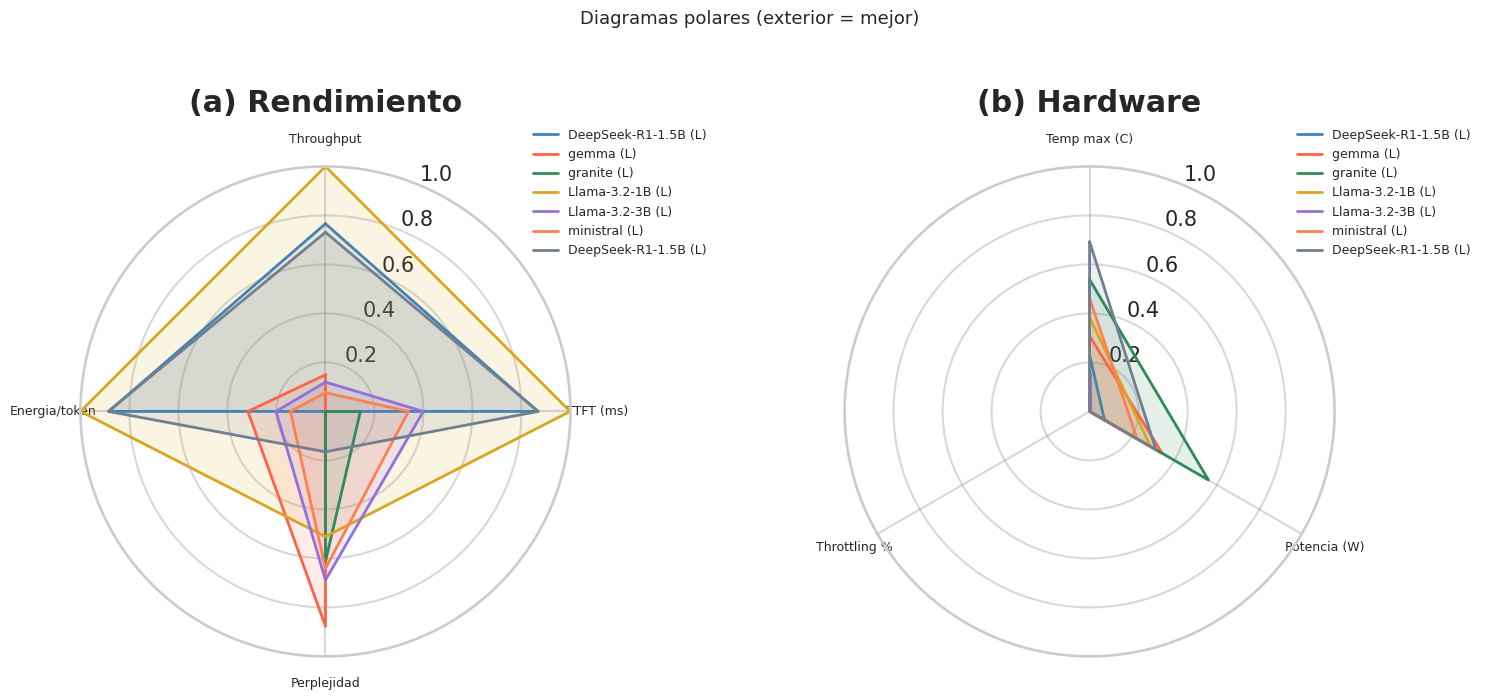

In [23]:
# Diagramas polares (rendimiento y hardware)
def _radar_chart(df, metrics, title, ax, colors):
    cols = [m[0] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        return
    labels = [m[1] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=15, fontweight="bold")
    for (_, row), color in zip(data.iterrows(), colors[:len(data)]):
        vals = []
        for col, _, higher_is_better in metrics:
            col_min, col_max = data[col].min(), data[col].max()
            rng = col_max - col_min if col_max != col_min else 1.0
            vals.append((data.loc[row.name, col] - col_min) / rng if higher_is_better
                        else (col_max - data.loc[row.name, col]) / rng)
        vals += vals[:1]
        ax.plot(angles, vals, lw=2, color=color, label=row["model_label"])
        ax.fill(angles, vals, alpha=0.12, color=color)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

perf_metrics = [
    ("tokens_per_s_mean",  "Throughput",      True),
    ("ttft_ms_mean",       "TTFT (ms)",        False),
    ("perplexity_geomean", "Perplejidad",      False),
    ("energy_per_token_j", "Energia/token",    False),
]
hw_metrics_radar = [
    ("temp_max_c",      "Temp max (C)", False),
    ("power_mean_w",    "Potencia (W)", False),
    ("throttled_ratio", "Throttling %", False),
]
colors_radar = ["steelblue", "tomato", "seagreen", "goldenrod", "mediumpurple", "coral", "slategray"]
fig = plt.figure(figsize=(16, 7))
perf_avail = [m for m in perf_metrics if m[0] in ex.columns]
hw_avail   = [m for m in hw_metrics_radar if m[0] in ex.columns]
if perf_avail:
    ax1 = fig.add_subplot(121, polar=True)
    _radar_chart(ex, perf_avail, "(a) Rendimiento", ax1, colors_radar)
if hw_avail:
    ax2 = fig.add_subplot(122, polar=True)
    _radar_chart(ex, hw_avail, "(b) Hardware", ax2, colors_radar)
fig.suptitle("Diagramas polares (exterior = mejor)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

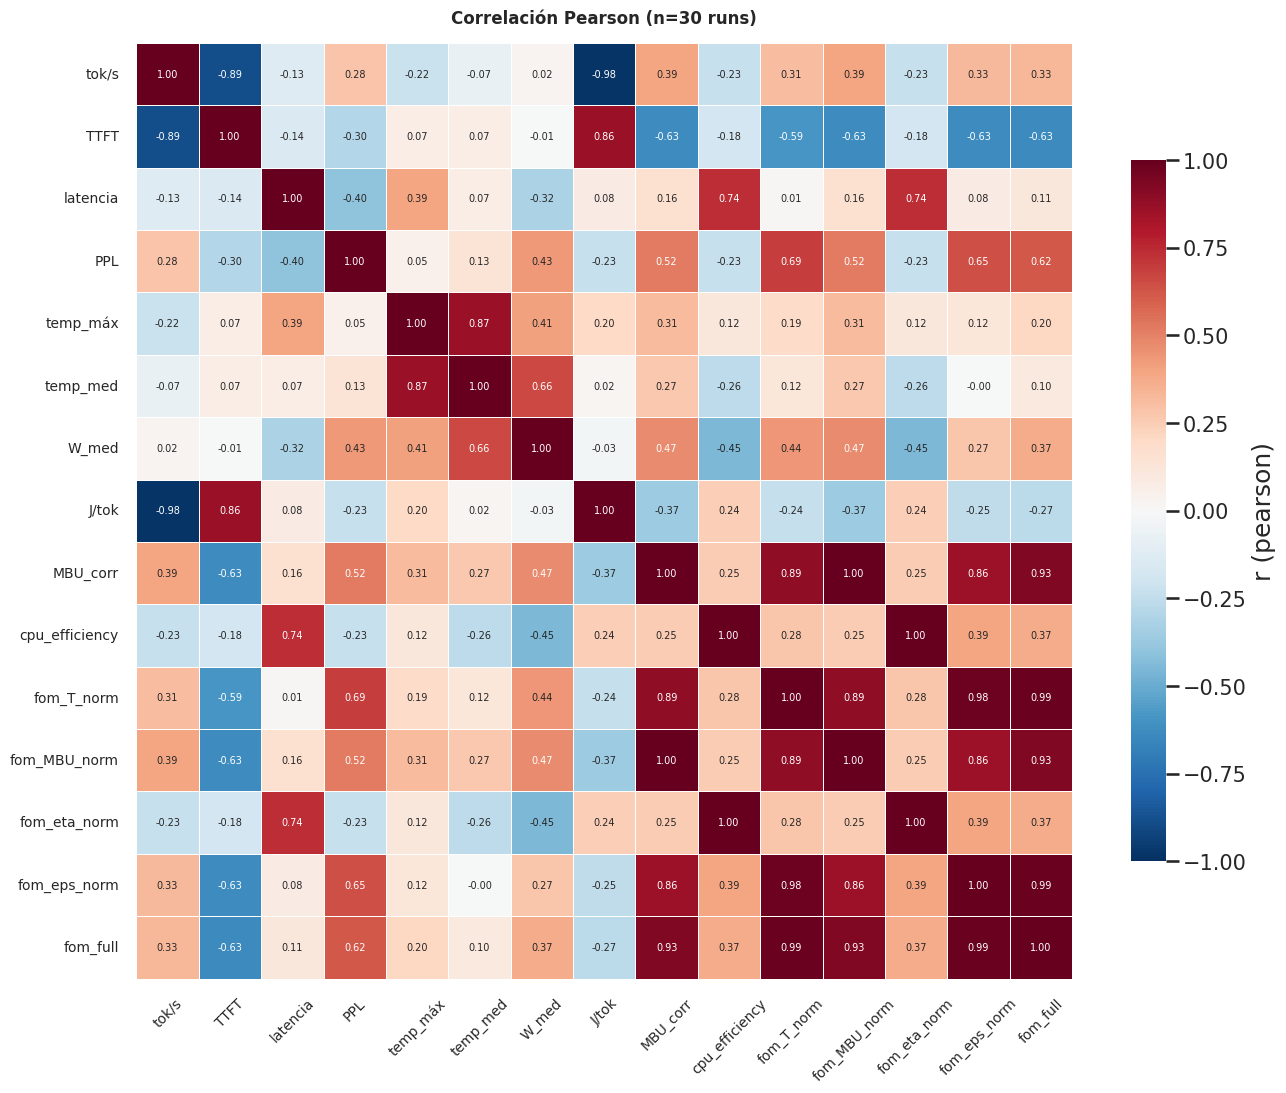

In [24]:
# Correlación de Pearson — incluye FoM_full, excluye throttling
try:
    from monitorviz.viz import correlation_heatmap
    from monitorviz.transforms.fom import compute_fom_full
    _ex_corr = compute_fom_full(ex)
    _pearson_cols = [c for c in [
        "tokens_per_s_mean", "ttft_ms_mean", "latency_ms_mean",
        "perplexity_geomean", "temp_max_c", "temp_mean_c",
        "power_mean_w", "energy_per_token_j", "mbu_corr",
        "cpu_efficiency", "fom_T_norm", "fom_MBU_norm",
        "fom_eta_norm", "fom_eps_norm", "fom_full",
    ] if c in _ex_corr.columns]
    if len(_ex_corr) >= 3:
        fig = correlation_heatmap(_ex_corr, cols=_pearson_cols,
                                  title=f"Correlación Pearson (n={len(_ex_corr)} runs)")
        plt.show()
    else:
        print(f"Datos insuficientes: {len(_ex_corr)} run(s), se necesitan >=3.")
except Exception as e:
    print(f"Error en correlación: {e}")


In [25]:
# ── E2 — Tabla/Matriz de correlaciones: contexto, FoM, energía, memoria ─────
try:
    from monitorviz.transforms.fom import compute_fom_full, compute_usability

    _corr2 = compute_fom_full(ex).copy()

    # Usabilidad
    _pm_c = pm_full[pm_full["run_id"].isin(ex["run_id"])].copy() if not pm_full.empty else pd.DataFrame()
    if not _pm_c.empty and not _corr2.empty:
        _corr2, _ = compute_usability(_corr2, _pm_c)
        _corr2["usable"] = _corr2["usable"].astype(float)

    # RAM desde hw_full
    if not hw_full.empty and "run_id" in hw_full.columns and "mem_used_bytes" in hw_full.columns:
        _ram2 = (hw_full.groupby("run_id")[["mem_used_bytes","mem_pct"]]
                 .max().reset_index())
        _ram2["mem_used_gb"] = _ram2["mem_used_bytes"] / 1e9
        _corr2 = _corr2.merge(_ram2[["run_id","mem_used_gb","mem_pct"]], on="run_id", how="left")

    _CORR2_COLS = {
        "context_size":       "Contexto",
        "n_params":           "N params",
        "model_size_gb":      "Modelo (GB)",
        "tokens_per_s_mean":  "tok/s",
        "ttft_ms_mean":       "TTFT (ms)",
        "energy_per_token_j": "J/tok",
        "mbu_corr":           "MBU (%)",
        "cpu_efficiency":     "η_CPU",
        "perplexity_geomean": "PPL",
        "mem_used_gb":        "RAM (GB)",
        "mem_pct":            "RAM (%)",
        "fom_full":           "FoM_full",
        "usable":             "Usable",
    }
    _avail2 = [c for c in _CORR2_COLS if c in _corr2.columns and _corr2[c].notna().any()]

    if len(_avail2) >= 3:
        _cdata2 = _corr2[_avail2].apply(pd.to_numeric, errors="coerce").dropna(how="all")
        _cmat2  = _cdata2.corr(method="pearson")
        _cmat2.columns = [_CORR2_COLS[c] for c in _avail2]
        _cmat2.index   = [_CORR2_COLS[c] for c in _avail2]

        print(f"Correlaciones Pearson (n={len(_cdata2)} runs):")
        display(_cmat2.round(3).style
                .background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)
                .format("{:.3f}"))

        # Columna clave: correlación con FoM_full
        if "FoM_full" in _cmat2.columns:
            _fom2 = (_cmat2["FoM_full"]
                     .drop("FoM_full")
                     .sort_values(key=abs, ascending=False))
            print("\nCorrelación con FoM_full (ordenada por |r|):")
            display(_fom2.rename("r").to_frame().round(3))

        # Columna: correlación con context_size
        if "Contexto" in _cmat2.columns:
            _ctx2 = (_cmat2["Contexto"]
                     .drop("Contexto")
                     .sort_values(key=abs, ascending=False))
            print("\nCorrelación con context_size:")
            display(_ctx2.rename("r").to_frame().round(3))
    else:
        print(f"Columnas insuficientes: {_avail2}")
except Exception as e:
    import traceback; traceback.print_exc()


Correlaciones Pearson (n=30 runs):


,Contexto,N params,Modelo (GB),tok/s,TTFT (ms),J/tok,MBU (%),η_CPU,PPL,RAM (GB),RAM (%),FoM_full,Usable
Contexto,1.000,0.000,0.000,-0.128,-0.001,0.068,-0.095,0.542,-0.408,0.158,0.158,-0.193,nan
N params,0.000,1.000,0.357,-0.857,0.586,0.907,-0.005,0.450,-0.012,0.920,0.920,0.150,nan
Modelo (GB),0.000,0.357,1.000,-0.738,0.918,0.667,-0.535,-0.347,-0.368,0.577,0.577,-0.672,nan
tok/s,-0.128,-0.857,-0.738,1.000,-0.890,-0.982,0.394,-0.228,0.284,-0.909,-0.909,0.332,nan
TTFT (ms),-0.001,0.586,0.918,-0.890,1.000,0.860,-0.633,-0.182,-0.296,0.712,0.712,-0.634,nan
J/tok,0.068,0.907,0.667,-0.982,0.860,1.000,-0.366,0.243,-0.234,0.934,0.934,-0.268,nan
MBU (%),-0.095,-0.005,-0.535,0.394,-0.633,-0.366,1.000,0.252,0.517,-0.126,-0.126,0.925,nan
η_CPU,0.542,0.450,-0.347,-0.228,-0.182,0.243,0.252,1.000,-0.233,0.393,0.393,0.369,nan
PPL,-0.408,-0.012,-0.368,0.284,-0.296,-0.234,0.517,-0.233,1.000,-0.254,-0.254,0.619,nan
RAM (GB),0.158,0.920,0.577,-0.909,0.712,0.934,-0.126,0.393,-0.254,1.000,1.000,-0.085,nan



Correlación con FoM_full (ordenada por |r|):


,r
MBU (%),0.925
Modelo (GB),-0.672
TTFT (ms),-0.634
PPL,0.619
η_CPU,0.369
tok/s,0.332
J/tok,-0.268
Contexto,-0.193
N params,0.150
RAM (%),-0.085



Correlación con context_size:


,r
η_CPU,0.542
PPL,-0.408
FoM_full,-0.193
RAM (GB),0.158
RAM (%),0.158
tok/s,-0.128
MBU (%),-0.095
J/tok,0.068
TTFT (ms),-0.001
N params,0.000


In [26]:
# Alertas y anomalías
alerts = []
if "throttled_ratio" in ex.columns:
    for _, row in ex[ex["throttled_ratio"] > 0.5].iterrows():
        alerts.append(f"throttling: {row['model_label']} ({row['throttled_ratio']*100:.1f}%)")
if "n_empty_generations" in ex.columns:
    for _, row in ex[ex["n_empty_generations"] > 0].iterrows():
        alerts.append(f"generaciones vacias: {row['model_label']} (n={int(row['n_empty_generations'])})")
if "tokens_per_s_mean" in ex.columns and len(ex) >= 3:
    mean_tps = ex["tokens_per_s_mean"].mean()
    std_tps  = ex["tokens_per_s_mean"].std()
    for _, row in ex[(ex["tokens_per_s_mean"] > mean_tps + 2 * std_tps) |
                     (ex["tokens_per_s_mean"] < mean_tps - 2 * std_tps)].iterrows():
        alerts.append(f"outlier throughput: {row['model_label']} ({row['tokens_per_s_mean']:.2f} tok/s)")
for a in alerts:
    print(f"ALERTA: {a}")
if not alerts:
    print("Sin alertas detectadas")

ALERTA: generaciones vacias: ministral (L) (n=1)
ALERTA: generaciones vacias: ministral (L) (n=1)
ALERTA: generaciones vacias: ministral (L) (n=1)
ALERTA: generaciones vacias: ministral (L) (n=1)
ALERTA: generaciones vacias: ministral (L) (n=1)
ALERTA: outlier throughput: Llama-3.2-1B (L) (13.12 tok/s)


## Figura de Mérito (FoM_full)

Combina cuatro ejes normalizados respecto a la configuración de referencia
(**llama3.2:3b · llama.cpp · Q4_K_M · ctx=4096 · bs=512**):

$$\text{FoM\_full} = \bigl(T_{norm} \cdot MBU_{norm} \cdot \eta_{norm} \cdot \varepsilon_{norm}\bigr)^{1/4}$$

| Eje | Normalización | Significado |
|-----|--------------|-------------|
| $T_{norm}$ | $N \cdot T / (N_{ref} T_{ref})$ | Throughput ponderado por tamaño |
| $MBU_{norm}$ | $\text{MBU\_corr} / \text{MBU}_{ref}$ | Utilización de ancho de banda (corregida) |
| $\eta_{norm}$ | $\eta_{CPU} / \eta_{ref}$ | Eficiencia computacional |
| $\varepsilon_{norm}$ | $N \cdot \varepsilon / (N_{ref} \varepsilon_{ref})$ | Tokens/J ponderados por tamaño |

**FoM_full > 1** → la configuración supera a la referencia en media geométrica.

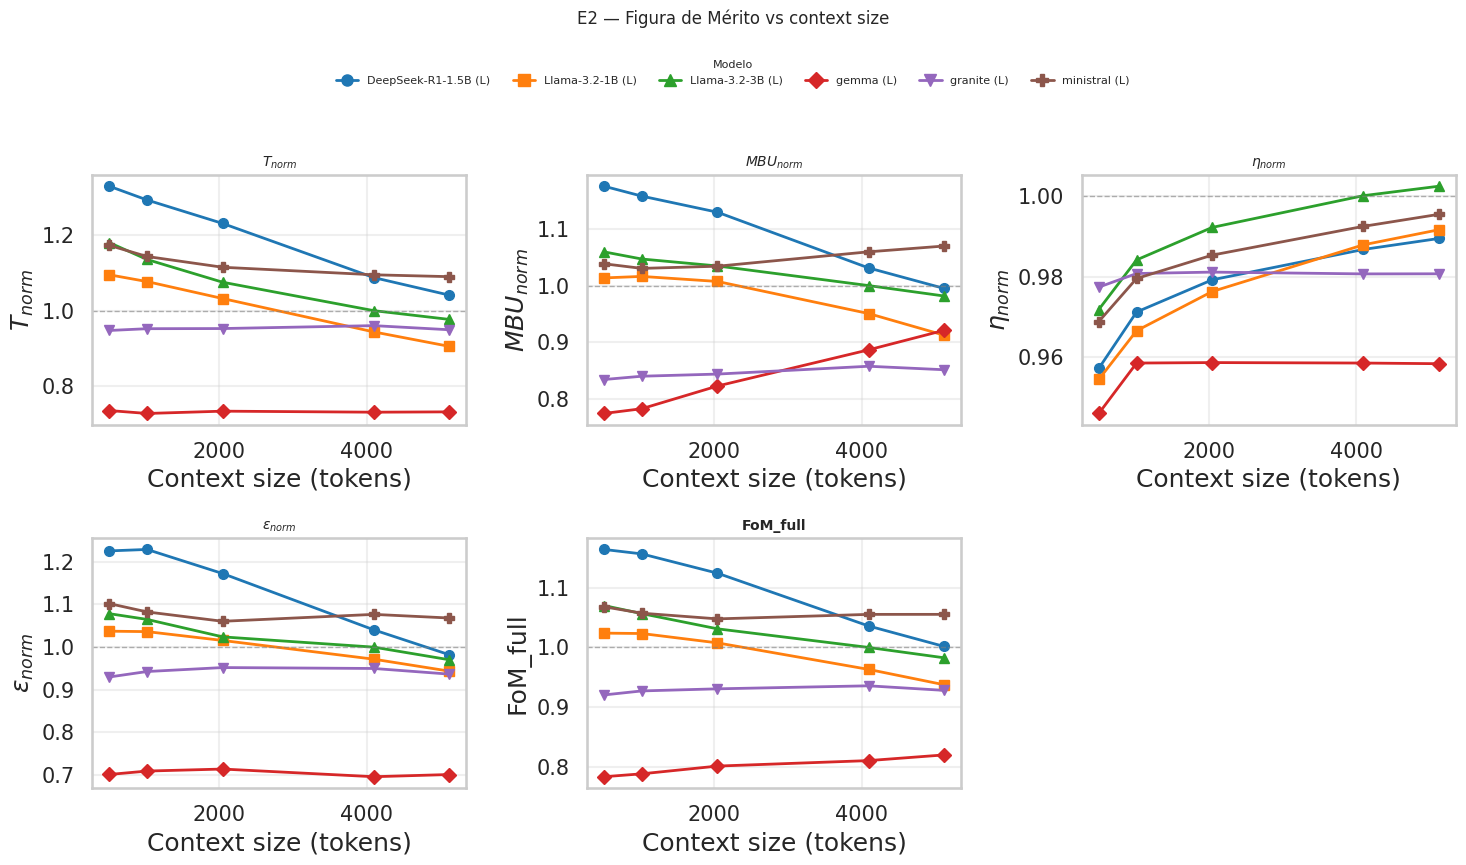


Criterio de usabilidad (≥3 palabras/s):


Context size,512,1024,2048,4096,5120
model_label,,,,,
DeepSeek-R1-1.5B (L),11.1 ✓,10.8 ✓,10.3 ✓,9.1 ✓,8.7 ✓
Llama-3.2-1B (L),13.1 ✓,12.9 ✓,12.4 ✓,11.3 ✓,10.8 ✓
Llama-3.2-3B (L),5.4 ✓,5.2 ✓,5.0 ✓,4.6 ✓,4.5 ✓
gemma (L),5.7 ✓,5.6 ✓,5.7 ✓,5.7 ✓,5.7 ✓
granite (L),4.4 ✓,4.4 ✓,4.4 ✓,4.5 ✓,4.4 ✓
ministral (L),5.1 ✓,4.9 ✓,4.8 ✓,4.7 ✓,4.7 ✓


Total usables: 30/30


In [27]:
# ── FoM_full — Figura de Mérito compuesta (E2) ──────────────────────────────
# x = context_size, una línea por modelo (color=modelo), ★ = usable
from monitorviz.transforms.fom import compute_fom_full, compute_usability

try:
    fom_df = compute_fom_full(ex)
    if not pm_full.empty:
        fom_df, _tpw = compute_usability(fom_df, pm_full)
    else:
        fom_df["usable"] = False

    _FOM_COLS = ["fom_T_norm", "fom_MBU_norm", "fom_eta_norm", "fom_eps_norm", "fom_full"]
    _avail = [c for c in _FOM_COLS if c in fom_df.columns and fom_df[c].notna().any()]
    _LABELS = {
        "fom_T_norm":   r"$T_{norm}$",
        "fom_MBU_norm": r"$MBU_{norm}$",
        "fom_eta_norm": r"$\eta_{norm}$",
        "fom_eps_norm": r"$\varepsilon_{norm}$",
        "fom_full":     "FoM_full",
    }
    _MODELS_F = sorted(fom_df["model_label"].unique())
    _MOD_COLORS = dict(zip(_MODELS_F,
                            ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown"]))
    _MK_POOL_F = ["o","s","^","D","v","P","X"]
    _MOD_MK_F  = {m: _MK_POOL_F[i % len(_MK_POOL_F)] for i, m in enumerate(_MODELS_F)}

    if _avail:
        ncols = min(3, len(_avail))
        nrows = (len(_avail) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes = np.array(axes).flatten() if hasattr(axes, "__len__") else [axes]

        for ax, col in zip(axes, _avail):
            fd = fom_df.dropna(subset=["context_size", col]).sort_values("context_size")
            for m in _MODELS_F:
                _sub = fd[fd["model_label"] == m]
                if _sub.empty: continue
                ax.plot(_sub["context_size"], _sub[col],
                        color=_MOD_COLORS[m], marker=_MOD_MK_F[m],
                        lw=2, ms=7, label=m)
            ax.axhline(1.0, color="gray", ls="--", lw=1, alpha=0.6)
            ax.set_xlabel("Context size (tokens)")
            ax.set_ylabel(_LABELS.get(col, col))
            ax.set_title(_LABELS.get(col, col), fontsize=10)
            ax.grid(True, alpha=0.3)

        for ax in axes[len(_avail):]:
            ax.set_visible(False)

        # Leyenda común arriba
        from matplotlib.lines import Line2D as _L2D
        _leg = [_L2D([0],[0], color=_MOD_COLORS[m], marker=_MOD_MK_F[m],
                     ms=8, lw=2, label=m) for m in _MODELS_F]
        fig.legend(handles=_leg, loc="upper center", bbox_to_anchor=(0.5, 1.04),
                   ncol=len(_leg), fontsize=8, title="Modelo", title_fontsize=8)
        fig.suptitle("E2 — Figura de Mérito vs context size", y=1.09, fontsize=12)
        fig.tight_layout()
        plt.show()

    # ── Usabilidad: pivot modelo × contexto ──────────────────────────────────
    if "usable" in fom_df.columns and "context_size" in fom_df.columns:
        print("\nCriterio de usabilidad (≥3 palabras/s):")
        _u = fom_df[["model_label", "context_size", "tokens_per_s_mean",
                      "T_hum", "usable", "fom_full"]].copy()
        _u["usable"] = _u["usable"].map({True: "✓", False: "✗"})
        _u["context_size"] = _u["context_size"].astype(int)
        # Pivot: filas=modelo, columnas=contexto, valor=tok/s (usable)
        _pivot = _u.pivot_table(
            index="model_label", columns="context_size",
            values="tokens_per_s_mean", aggfunc="mean"
        ).round(1)
        _pivot_u = _u.pivot_table(
            index="model_label", columns="context_size",
            values="usable", aggfunc="first"
        )
        # Combinar tok/s + ✓/✗
        _disp = _pivot.copy().astype(str)
        for col in _pivot.columns:
            if col in _pivot_u.columns:
                _disp[col] = _pivot[col].apply(lambda x: f"{x:.1f}") + " " + _pivot_u[col].fillna("?")
        _disp.columns.name = "Context size"
        display(_disp)
        n_usable = (fom_df["usable"] == True).sum()
        print(f"Total usables: {n_usable}/{len(fom_df)}")

except Exception:
    import traceback; traceback.print_exc()


## Conclusiones y discusión

### Confirmación/refutación de hipótesis
> TODO

### Hallazgos principales
> TODO

### Limitaciones
> TODO